# Reproducible Cross-Event Rumor Detection on PHEME: RoBERTa, User Credibility, and Propagation Graphs

**Author:** Muhammad Basit
**Advisor:** Dr. Ademola Adesokan

---

## Abstract

We study early rumor detection on Twitter using the PHEME dataset under the *Leave-One-Event-Out* (LOEO) protocol, which approximates the real-world setting.

In this setting, a model must generalize to a previously unseen breaking-news event.

Each conversation is represented as a propagation graph whose nodes carry a fused representation of:

* RoBERTa source-tweet embeddings
* Per-tweet user-credibility features
* The reply-tree structure

We compare a plain GCN baseline with a **Bi-directional GCN (Bi-GCN)** that fuses a top-down propagation pass with a bottom-up dispersion pass.

We evaluate:

* DropEdge regularization
* Temporal sub-tree growth
* Early-detection curves
* Controlled feature ablation

All results are reported as *mean ± std* across LOEO folds using:

* Accuracy
* Macro-F1
* Rumor-class F1

---

## Notebook Layout

| Section | Content                                                               |
| ------- | --------------------------------------------------------------------- |
| 1       | Environment, configuration, reproducibility                           |
| 2       | PHEME loading, user features, tree construction, timestamps           |
| 3       | RoBERTa source-tweet encoding (cached)                                |
| 4       | PyG dataset builder (configurable features × structure × time)        |
| 5       | Model architectures: GCN, Bi-GCN                                      |
| 6       | Shared LOEO training engine with **honest** validation early-stopping |
| 7       | **Experiment 1** — GCN vs. Bi-GCN baselines                           |
| 8       | **Experiment 2** — DropEdge sweep over p ∈ {0.0, 0.1, 0.2, 0.3}       |
| 9       | **Experiment 3** — Temporal snapshots (25% / 50% / 100% by time)      |
| 10      | **Experiment 4** — Early detection curves (10% / 25% / 50% observed)  |
| 11      | **Experiment 5** — Feature ablation (text / user / structure / time)  |
| 12      | Final summary table, per-event table, confusion matrices              |

## Reproducibility note

Run the notebook from top to bottom after placing the PHEME dataset in the
expected local data directory. Cached embeddings and experiment outputs are
generated locally and are intentionally excluded from version control.


In [1]:
# ## 1. Setup and Configuration

# All hyperparameters are defined within this single cell, ensuring that the rest of the notebook remains parameter-free and easy to follow.

# Random seeds are fixed to ensure reproducibility across experiments, allowing consistent and comparable results.



In [2]:
# 1.1 Imports
import os
import json
import copy
import pickle
import random
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


C:\Users\mBasit\AppData\Local\anaconda3\envs\ml_gpu\lib\site-packages\accelerate\utils\torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# 1.2 Configuration (Final GPU Fix)
import os
import torch
import numpy as np
import random

CONFIG = {
    "PHEME_ROOT":      "./pheme_data/all-rnr-annotated-threads",
    "ZIP_NAME":        "all-rnr-annotated-threads.zip",
    "ZIP_SEARCH_DIRS": [".", "..", os.path.expanduser("~/Downloads")],
    "CACHE_DIR":       "./cache",
    "RESULTS_DIR":     "./results",
    "MODELS_DIR":      "./saved_models",
    "SEED":            42,
    "ROBERTA_NAME":    "roberta-base",
    "ROBERTA_MAXLEN":  128,
    "ROBERTA_BATCH":   16,
    "TEXT_DIM":        768,
    "USER_DIM":        5,
    "EPOCHS":          40,
    "BATCH_SIZE":      32,
    "LR":              1e-3,
    "WEIGHT_DECAY":    1e-4,
    "PATIENCE":        6,
    "VAL_FRAC":        0.10,
    "MIN_THREADS_PER_FOLD": 5,
    "CLASS_WEIGHT_MODE": "balanced",
    "TEMPORAL_RATIOS": [0.25, 0.50, 1.00],
    "EARLY_RATIOS":    [0.10, 0.25, 0.50, 1.00],
    "DROPEDGE_PROBS":  [0.0, 0.1, 0.2, 0.3],
}

# Directory Setup
for d in [CONFIG["CACHE_DIR"], CONFIG["RESULTS_DIR"], CONFIG["MODELS_DIR"]]:
    os.makedirs(d, exist_ok=True)

# GPU Stability Logic for RTX 2080 + Driver 457.51
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    # CRITICAL for older drivers to avoid the PTX error
    torch.backends.cudnn.enabled = True
    torch.backends.cudnn.benchmark = False
    print(f"STATUS: GPU is active - {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("STATUS: GPU not compatible, using CPU.")

CONFIG["DEVICE"] = DEVICE

# Reproducibility
random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["SEED"])

STATUS: GPU is active - GeForce RTX 2080


In [4]:
# 1.3 Reproducibility

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["SEED"])
print(f"Seed pinned to {CONFIG['SEED']}.")


Seed pinned to 42.


In [5]:
# ## 2. PHEME data pipeline

# ### 2.1 Locate and extract the dataset

# PHEME ships as a zip archive with one folder per event, each containing
# `rumours/` and `non-rumours/` sub-folders. Each thread carries the source
# tweet, the reaction tweets, an `annotation.json` with the ground-truth
# veracity, and a `structure.json` with the reply tree.


In [6]:
# 2.1 Locate and extract the PHEME zip
import zipfile

def locate_zip(zip_name: str, search_dirs, manual_path: str = None) -> str | None:
    if manual_path and os.path.exists(manual_path):
        return os.path.abspath(manual_path)
    for d in search_dirs:
        candidate = os.path.join(d, zip_name)
        if os.path.exists(candidate):
            return os.path.abspath(candidate)
    return None

if not os.path.exists(CONFIG["PHEME_ROOT"]):
    zpath = locate_zip(CONFIG["ZIP_NAME"], CONFIG["ZIP_SEARCH_DIRS"],
                       CONFIG["MANUAL_ZIP_PATH"])
    if zpath is None:
        raise FileNotFoundError(
            f"Could not find {CONFIG['ZIP_NAME']}. "
            f"Set CONFIG['MANUAL_ZIP_PATH']."
        )
    print(f"Extracting {zpath} ...")
    extract_to = os.path.dirname(CONFIG["PHEME_ROOT"]) or "."
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(extract_to)

events = sorted(d for d in os.listdir(CONFIG["PHEME_ROOT"])
                if not d.startswith(".") and
                os.path.isdir(os.path.join(CONFIG["PHEME_ROOT"], d)))
print(f"Found {len(events)} events:")
for e in events:
    print(f"  - {e}")


Found 9 events:
  - charliehebdo-all-rnr-threads
  - ebola-essien-all-rnr-threads
  - ferguson-all-rnr-threads
  - germanwings-crash-all-rnr-threads
  - gurlitt-all-rnr-threads
  - ottawashooting-all-rnr-threads
  - prince-toronto-all-rnr-threads
  - putinmissing-all-rnr-threads
  - sydneysiege-all-rnr-threads


In [7]:
# 2.2 Load thread-level metadata (text + label)

def _safe_open_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def load_pheme_threads(pheme_root: str) -> pd.DataFrame:
    rows = []
    for event in sorted(os.listdir(pheme_root)):
        if event.startswith("."):
            continue
        ev_path = os.path.join(pheme_root, event)
        if not os.path.isdir(ev_path):
            continue
        for cat in ("rumours", "non-rumours"):
            cat_path = os.path.join(ev_path, cat)
            if not os.path.isdir(cat_path):
                continue
            for thread_id in sorted(os.listdir(cat_path)):
                if thread_id.startswith("."):
                    continue
                t_path = os.path.join(cat_path, thread_id)
                if not os.path.isdir(t_path):
                    continue

                # Label: prefer annotation.json, fall back to folder
                ann = _safe_open_json(os.path.join(t_path, "annotation.json"))
                if ann is not None and "is_rumour" in ann:
                    label = 1 if str(ann["is_rumour"]).lower() in ("rumour", "true", "1") else 0
                else:
                    label = 1 if cat == "rumours" else 0

                # Source-tweet text
                text = ""
                for src_dir in ("source-tweets", "source-tweet"):
                    sp = os.path.join(t_path, src_dir)
                    if not os.path.isdir(sp):
                        continue
                    for fname in sorted(os.listdir(sp)):
                        if fname.endswith(".json"):
                            tj = _safe_open_json(os.path.join(sp, fname))
                            if tj and tj.get("text"):
                                text = tj["text"]
                                break
                    if text:
                        break
                if not text:
                    continue
                rows.append({
                    "event":     event,
                    "thread_id": str(thread_id),
                    "text":      text,
                    "label":     label,
                })
    return pd.DataFrame(rows)

df = load_pheme_threads(CONFIG["PHEME_ROOT"])
df["thread_id"] = df["thread_id"].astype(str)
df.to_csv(os.path.join(CONFIG["CACHE_DIR"], "pheme_threads.csv"), index=False)
print(f"Loaded {len(df)} threads.")
print(df.groupby("event")["label"].agg(["count", "sum"]).rename(
    columns={"count": "threads", "sum": "rumours"}))


Loaded 6425 threads.
                                   threads  rumours
event                                              
charliehebdo-all-rnr-threads          2079      458
ebola-essien-all-rnr-threads            14       14
ferguson-all-rnr-threads              1143      284
germanwings-crash-all-rnr-threads      469      238
gurlitt-all-rnr-threads                138       61
ottawashooting-all-rnr-threads         890      470
prince-toronto-all-rnr-threads         233      229
putinmissing-all-rnr-threads           238      126
sydneysiege-all-rnr-threads           1221      522


In [8]:
# 2.3 Extract user-credibility features for every tweet

def extract_user_credibility(tweet_json: dict) -> list[float]:
    try:
        u = tweet_json["user"]
        verified  = 1 if u.get("verified", False) else 0
        followers = float(np.log1p(u.get("followers_count", 0) or 0))
        statuses  = float(np.log1p(u.get("statuses_count",  0) or 0))
        listed    = float(np.log1p(u.get("listed_count",    0) or 0))
        created   = datetime.strptime(u["created_at"],
                                      "%a %b %d %H:%M:%S +0000 %Y")
        age       = float(np.log1p(max(0, (datetime.now() - created).days)))
        return [verified, followers, statuses, listed, age]
    except Exception:
        return [0.0, 0.0, 0.0, 0.0, 0.0]

def collect_user_features(pheme_root: str) -> pd.DataFrame:
    rows = []
    for event in sorted(os.listdir(pheme_root)):
        if event.startswith("."):
            continue
        ev_path = os.path.join(pheme_root, event)
        if not os.path.isdir(ev_path):
            continue
        for cat in ("rumours", "non-rumours"):
            cat_path = os.path.join(ev_path, cat)
            if not os.path.isdir(cat_path):
                continue
            for thread_id in sorted(os.listdir(cat_path)):
                t_path = os.path.join(cat_path, thread_id)
                if not os.path.isdir(t_path):
                    continue
                for sub in ("source-tweets", "source-tweet", "reactions"):
                    sp = os.path.join(t_path, sub)
                    if not os.path.isdir(sp):
                        continue
                    for fname in os.listdir(sp):
                        if not fname.endswith(".json"):
                            continue
                        full = os.path.join(sp, fname)
                        if os.path.getsize(full) == 0:
                            continue
                        tj = _safe_open_json(full)
                        if not tj:
                            continue
                        tid = str(tj.get("id_str", tj.get("id", "")))
                        if not tid:
                            continue
                        rows.append([tid] + extract_user_credibility(tj))
    cols = ["tweet_id", "verified", "followers", "activity", "listed", "age"]
    return pd.DataFrame(rows, columns=cols).drop_duplicates(subset="tweet_id")

USER_CACHE = os.path.join(CONFIG["CACHE_DIR"], "user_features.csv")
if os.path.exists(USER_CACHE):
    df_user = pd.read_csv(USER_CACHE)
    df_user["tweet_id"] = df_user["tweet_id"].astype(str)
    print(f"Loaded {len(df_user)} cached user-feature rows.")
else:
    df_user = collect_user_features(CONFIG["PHEME_ROOT"])
    df_user["tweet_id"] = df_user["tweet_id"].astype(str)
    df_user.to_csv(USER_CACHE, index=False)
    print(f"Collected {len(df_user)} user-feature rows.")


Loaded 104582 cached user-feature rows.


In [9]:
# 2.4 Build propagation trees and tweet timestamps in one pass

def build_trees_and_times(pheme_root: str):
    trees, time_map = {}, {}
    for event in sorted(os.listdir(pheme_root)):
        if event.startswith("."):
            continue
        ev_path = os.path.join(pheme_root, event)
        if not os.path.isdir(ev_path):
            continue
        for cat in ("rumours", "non-rumours"):
            cat_path = os.path.join(ev_path, cat)
            if not os.path.isdir(cat_path):
                continue
            for thread_id in sorted(os.listdir(cat_path)):
                t_path = os.path.join(cat_path, thread_id)
                if not os.path.isdir(t_path):
                    continue

                # Tree
                struct = _safe_open_json(os.path.join(t_path, "structure.json"))
                if struct:
                    G = nx.DiGraph()
                    def add(parent, children):
                        G.add_node(str(parent))
                        if isinstance(children, dict):
                            for c, sub in children.items():
                                G.add_edge(str(parent), str(c))
                                add(c, sub)
                        elif isinstance(children, list):
                            for c in children:
                                G.add_edge(str(parent), str(c))
                    for root, replies in struct.items():
                        add(root, replies)
                    if G.number_of_nodes() > 0:
                        trees[str(thread_id)] = G

                # Timestamps
                for sub in ("source-tweets", "source-tweet", "reactions"):
                    sp = os.path.join(t_path, sub)
                    if not os.path.isdir(sp):
                        continue
                    for fname in os.listdir(sp):
                        if not fname.endswith(".json"):
                            continue
                        full = os.path.join(sp, fname)
                        if os.path.getsize(full) == 0:
                            continue
                        tj = _safe_open_json(full)
                        if not tj or "created_at" not in tj:
                            continue
                        tid = str(tj.get("id_str", tj.get("id", "")))
                        if tid:
                            time_map[tid] = tj["created_at"]
    return trees, time_map

trees, tweet_time_map = build_trees_and_times(CONFIG["PHEME_ROOT"])
print(f"Built {len(trees)} propagation trees.")
print(f"Collected {len(tweet_time_map)} tweet timestamps.")

# Drop threads we have metadata for but no tree (a few do exist)
df = df[df["thread_id"].isin(trees.keys())].reset_index(drop=True)
print(f"Threads with valid trees: {len(df)}")


Built 6425 propagation trees.
Collected 104582 tweet timestamps.
Threads with valid trees: 6425


In [10]:
# ## 3. RoBERTa source-tweet embeddings

# We encode each source tweet once with a pre-trained RoBERTa model and cache
# the `[CLS]` representation to disk. This embedding is broadcast to every node
# in the propagation tree as the textual context of the conversation.


In [11]:
# 3.1 Encode (or load cached) source-tweet embeddings

EMBED_CACHE = os.path.join(CONFIG["CACHE_DIR"], "source_embeddings.pt")

def encode_source_embeddings(df: pd.DataFrame, batch_size: int = 16) -> dict:
    tokenizer = RobertaTokenizer.from_pretrained(CONFIG["ROBERTA_NAME"])
    model = RobertaModel.from_pretrained(CONFIG["ROBERTA_NAME"]).to(DEVICE).eval()

    out = {}
    texts, tids = df["text"].tolist(), df["thread_id"].tolist()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            chunk = texts[i:i + batch_size]
            enc = tokenizer(chunk, padding=True, truncation=True,
                            max_length=CONFIG["ROBERTA_MAXLEN"],
                            return_tensors="pt").to(DEVICE)
            cls = model(**enc).last_hidden_state[:, 0, :].cpu()
            for j, tid in enumerate(tids[i:i + batch_size]):
                out[tid] = cls[j]
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return out

if os.path.exists(EMBED_CACHE):
    source_embeddings = torch.load(EMBED_CACHE)
    print(f"Loaded {len(source_embeddings)} cached embeddings from disk.")
else:
    print("Encoding source tweets with RoBERTa ...")
    source_embeddings = encode_source_embeddings(df, batch_size=CONFIG["ROBERTA_BATCH"])
    torch.save(source_embeddings, EMBED_CACHE)
    print(f"Cached {len(source_embeddings)} embeddings to {EMBED_CACHE}.")


Loaded 6425 cached embeddings from disk.


In [12]:
# ## 4. PyG dataset builder

# A *single* dataset builder handles every experiment. The flags decide which
# modalities are used and whether the propagation structure is preserved or
# scrambled into self-loops (used by the structure-ablation variant).

# ```
# build_dataset(use_text, use_user, use_structure, snapshot_ratio=1.0)
# ```

# | flag | effect |
# |---|---|
# | `use_text` | concatenate the 768-d RoBERTa embedding to every node |
# | `use_user` | concatenate the 5-d user-credibility vector to every node |
# | `use_structure` | keep the reply-tree edges; otherwise use only self-loops |
# | `snapshot_ratio` | keep only the first `r·N` nodes ordered by tweet timestamp |

# The output is a list of PyG `Data` objects with `event` and `thread_id`
# attached, ready for LOEO splitting.


In [13]:
# 4.1 Configurable PyG dataset builder

def _node_user_vec(user_map: dict, n: str) -> torch.Tensor:
    u = user_map.get(n, {})
    return torch.tensor([
        float(u.get("verified", 0)),
        float(u.get("followers", 0)),
        float(u.get("activity", 0)),
        float(u.get("listed", 0)),
        float(u.get("age", 0)),
    ], dtype=torch.float32)

def _ordered_nodes_by_time(G: nx.DiGraph, time_map: dict) -> list[str]:
    '''Return graph nodes in chronological order, falling back to insertion order.'''
    timed = []
    for n in G.nodes():
        ts = time_map.get(str(n))
        if ts is None:
            continue
        try:
            t = datetime.strptime(ts, "%a %b %d %H:%M:%S +0000 %Y")
        except ValueError:
            continue
        timed.append((str(n), t))
    timed.sort(key=lambda x: x[1])
    ordered = [n for n, _ in timed]
    # Append any remaining nodes (no timestamp) at the end so they're
    # only ever included in the 100 % snapshot.
    untimed = [str(n) for n in G.nodes() if str(n) not in {x[0] for x in timed}]
    return ordered + untimed

def build_dataset(use_text: bool = True,
                  use_user: bool = True,
                  use_structure: bool = True,
                  snapshot_ratio: float = 1.0,
                  *,
                  text_dim: int = 768,
                  user_dim: int = 5,
                  dummy_dim: int = 16) -> list[Data]:
    '''Construct a PyG dataset under the given feature/structure/time config.'''
    label_map = df.set_index("thread_id")["label"].to_dict()
    event_map = df.set_index("thread_id")["event"].to_dict()
    user_map  = df_user.set_index("tweet_id").to_dict("index")

    dataset = []
    for tid, G in trees.items():
        if tid not in label_map:
            continue

        # Order nodes by timestamp; trim to snapshot ratio
        ordered = _ordered_nodes_by_time(G, tweet_time_map)
        if not ordered:
            ordered = [str(n) for n in G.nodes()]
        cutoff = max(1, int(round(len(ordered) * snapshot_ratio)))
        keep = ordered[:cutoff]
        if not keep:
            continue
        node_idx = {n: i for i, n in enumerate(keep)}
        keep_set = set(keep)

        # Build node features per the modality flags
        src = source_embeddings.get(tid, torch.zeros(text_dim))
        feats = []
        for n in keep:
            parts = []
            if use_text:
                parts.append(src)
            if use_user:
                parts.append(_node_user_vec(user_map, n))
            if not parts:                       # structure-only: dummy const features
                parts.append(torch.ones(dummy_dim))
            feats.append(torch.cat(parts))

        # Edges
        if use_structure:
            edges = [[node_idx[str(u)], node_idx[str(v)]]
                     for u, v in G.edges()
                     if str(u) in keep_set and str(v) in keep_set]
        else:
            edges = [[i, i] for i in range(len(keep))]    # self-loops only
        if not edges:
            edges = [[i, i] for i in range(len(keep))]

        dataset.append(Data(
            x=torch.stack(feats).float(),
            edge_index=torch.tensor(edges, dtype=torch.long).t().contiguous(),
            y=torch.tensor([label_map[tid]], dtype=torch.long),
            event=event_map[tid],
            thread_id=tid,
        ))
    return dataset

# Sanity check: build the full default dataset once to validate
gnn_dataset = build_dataset(use_text=True, use_user=True, use_structure=True,
                            snapshot_ratio=1.0)
INPUT_DIM = gnn_dataset[0].x.size(1)
print(f"Built {len(gnn_dataset)} graphs, input_dim = {INPUT_DIM}")

EVENTS = sorted({d.event for d in gnn_dataset})
print(f"Events ({len(EVENTS)}):")
for e in EVENTS:
    n = sum(1 for d in gnn_dataset if d.event == e)
    pos = sum(1 for d in gnn_dataset if d.event == e and int(d.y) == 1)
    print(f"  {e:40s}  total={n:5d}  rumours={pos:5d}  non-rumours={n-pos:5d}")


Built 6425 graphs, input_dim = 773
Events (9):
  charliehebdo-all-rnr-threads              total= 2079  rumours=  458  non-rumours= 1621
  ebola-essien-all-rnr-threads              total=   14  rumours=   14  non-rumours=    0
  ferguson-all-rnr-threads                  total= 1143  rumours=  284  non-rumours=  859
  germanwings-crash-all-rnr-threads         total=  469  rumours=  238  non-rumours=  231
  gurlitt-all-rnr-threads                   total=  138  rumours=   61  non-rumours=   77
  ottawashooting-all-rnr-threads            total=  890  rumours=  470  non-rumours=  420
  prince-toronto-all-rnr-threads            total=  233  rumours=  229  non-rumours=    4
  putinmissing-all-rnr-threads              total=  238  rumours=  126  non-rumours=  112
  sydneysiege-all-rnr-threads               total= 1221  rumours=  522  non-rumours=  699


In [14]:
# ## 5. Model architectures

# ### 5.1 GCN baseline
# A plain three-layer GCN with global mean pooling. This is the simplest
# graph baseline and matches what we had in our previous experiments.

# ### 5.2 Bi-GCN (Bian et al., AAAI 2020)
# Per the advisor's first request, we include the Bi-directional GCN, which
# runs two independent passes:

# * **Top-Down (TD)**: edges as given (parent → child); models *propagation*.
# * **Bottom-Up (BU)**: edges reversed (child → parent); models *dispersion*.

# The two pooled representations are concatenated and fed into an MLP
# classifier. We add a learnable feature-projection layer with BatchNorm in
# front of both branches because the input dimension (768 + 5 = 773) is
# heavily dominated by the RoBERTa block, and the user-credibility scalars
# need normalization to compete.

# Both architectures take an optional `dropedge_p` argument; when non-zero
# (and during training only), we randomly drop a fraction of edges before
# each forward pass — this is Experiment 2.


In [15]:
# 5.1 Edge dropout helper (DropEdge, Rong et al., ICLR 2020)

def drop_edges(edge_index: torch.Tensor, p: float, training: bool) -> torch.Tensor:
    if (not training) or p <= 0.0 or edge_index.size(1) == 0:
        return edge_index
    mask = torch.rand(edge_index.size(1), device=edge_index.device) > p
    if mask.sum() == 0:
        # keep at least one edge to avoid empty edge_index
        mask[torch.randint(0, edge_index.size(1), (1,))] = True
    return edge_index[:, mask]


In [16]:
# 5.2 GCN baseline

class GCN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 num_classes: int = 2, dropedge_p: float = 0.0,
                 dropout: float = 0.3):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.conv3 = GCNConv(hidden_dim // 2, hidden_dim // 4)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim // 4, num_classes)
        self.dropedge_p = dropedge_p

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_index = drop_edges(edge_index, self.dropedge_p, self.training)

        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)
        return self.fc(x)


In [17]:
# 5.3 Bi-GCN: Top-Down + Bottom-Up + fusion

class BiGCN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 num_classes: int = 2, dropedge_p: float = 0.0,
                 dropout: float = 0.3):
        super().__init__()

        # Project the heterogeneous (text, user) feature space into a clean
        # latent space before either GCN branch consumes it.
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Top-Down
        self.td_conv1 = GCNConv(hidden_dim, hidden_dim)
        self.td_conv2 = GCNConv(hidden_dim, hidden_dim // 2)

        # Bottom-Up
        self.bu_conv1 = GCNConv(hidden_dim, hidden_dim)
        self.bu_conv2 = GCNConv(hidden_dim, hidden_dim // 2)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )
        self.dropedge_p = dropedge_p

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.proj(x)

        td_edge = drop_edges(edge_index, self.dropedge_p, self.training)
        td = F.relu(self.td_conv1(x, td_edge))
        td = self.dropout(td)
        td = F.relu(self.td_conv2(td, td_edge))
        td_pool = global_mean_pool(td, batch)

        bu_edge = drop_edges(edge_index.flip(0), self.dropedge_p, self.training)
        bu = F.relu(self.bu_conv1(x, bu_edge))
        bu = self.dropout(bu)
        bu = F.relu(self.bu_conv2(bu, bu_edge))
        bu_pool = global_mean_pool(bu, batch)

        h = torch.cat([td_pool, bu_pool], dim=1)
        return self.fc(h)


In [18]:
# ## 6. LOEO training engine

# A single function trains and evaluates *any* model under the
# Leave-One-Event-Out protocol. The two important methodological points:

# 1. **Validation is held out from the *training* events**, never from the
#    test event. We carve out `VAL_FRAC` of the training graphs (stratified
#    by label) for early stopping. This avoids the silent test-set leakage
#    that arises when one stops on the test event itself.
# 2. **Class weights** are computed from the training fold via
#    `n_samples / (n_classes · n_class_samples)` (the classic "balanced"
#    formula from sklearn). This avoids hand-picked magic numbers.

# The function returns one record per fold:
# `{"event": ..., "y_true": [...], "y_pred": [...], "n_train": int, "n_val": int}`.


In [19]:
# 6.1 Helper: per-fold metrics

def fold_metrics(y_true, y_pred):
    '''Return (accuracy, macro_f1, rumor_f1) — robust to single-class folds.'''
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro", zero_division=0),
        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    )

def class_weights_from_labels(labels: list[int]) -> torch.Tensor:
    '''sklearn-style 'balanced' weights, returned on DEVICE.'''
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    weights = np.ones(2, dtype=np.float32)
    n = len(labels)
    for c, k in zip(classes, counts):
        weights[c] = n / (len(classes) * k)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


In [20]:
# 6.2 LOEO training loop with validation-based early stopping

def train_loeo(model_factory,
               dataset: list[Data],
               *,
               events: list[str] = None,
               epochs: int = None,
               batch_size: int = None,
               lr: float = None,
               weight_decay: float = None,
               patience: int = None,
               val_frac: float = None,
               class_weight_mode: str = None,
               verbose: bool = True,
               tag: str = "model") -> list[dict]:
    '''
    Run Leave-One-Event-Out training/eval. `model_factory()` must return a
    fresh nn.Module each time.

    Methodological note: the validation split used for early stopping is
    drawn from the training events (stratified by label) — *never* from the
    held-out test event.
    '''
    epochs            = epochs            or CONFIG["EPOCHS"]
    batch_size        = batch_size        or CONFIG["BATCH_SIZE"]
    lr                = lr                or CONFIG["LR"]
    weight_decay      = weight_decay      if weight_decay is not None else CONFIG["WEIGHT_DECAY"]
    patience          = patience          or CONFIG["PATIENCE"]
    val_frac          = val_frac          if val_frac is not None else CONFIG["VAL_FRAC"]
    class_weight_mode = class_weight_mode or CONFIG["CLASS_WEIGHT_MODE"]
    if events is None:
        events = sorted({d.event for d in dataset})

    fold_records = []

    for test_event in events:
        train_pool = [d for d in dataset if d.event != test_event]
        test_data  = [d for d in dataset if d.event == test_event]
        if len(test_data) < CONFIG["MIN_THREADS_PER_FOLD"]:
            if verbose:
                print(f"  [{tag}] skipping fold '{test_event}' (only {len(test_data)} threads)")
            continue
        # Stratified val split from the training pool
        labels = [int(d.y) for d in train_pool]
        if min(np.bincount(labels)) < 2:
            train_data, val_data = train_pool, []
        else:
            train_idx, val_idx = train_test_split(
                np.arange(len(train_pool)), test_size=val_frac,
                stratify=labels, random_state=CONFIG["SEED"])
            train_data = [train_pool[i] for i in train_idx]
            val_data   = [train_pool[i] for i in val_idx]

        train_loader = GeoDataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader   = GeoDataLoader(val_data,   batch_size=batch_size) if val_data else None
        test_loader  = GeoDataLoader(test_data,  batch_size=batch_size)

        model = model_factory().to(DEVICE)
        optim = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)

        if class_weight_mode == "balanced":
            cw = class_weights_from_labels([int(d.y) for d in train_data])
        else:
            cw = None

        best_state, best_val_f1 = None, -1.0
        epochs_without_improvement = 0

        for epoch in range(epochs):
            # ------ train ------
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optim.zero_grad()
                out = model(batch)
                loss = F.cross_entropy(out, batch.y, weight=cw)
                loss.backward()
                optim.step()

            # ------ validate ------
            if val_loader is None:
                continue
            model.eval()
            v_true, v_pred = [], []
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(DEVICE)
                    pred = model(batch).argmax(1).cpu().tolist()
                    v_pred += pred
                    v_true += batch.y.cpu().tolist()
            v_f1 = f1_score(v_true, v_pred, average="macro", zero_division=0)
            if v_f1 > best_val_f1:
                best_val_f1 = v_f1
                best_state = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    break

        # ------ final test ------
        if best_state is not None:
            model.load_state_dict(best_state)
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(DEVICE)
                pred = model(batch).argmax(1).cpu().tolist()
                y_pred += pred
                y_true += batch.y.cpu().tolist()

        acc, mf1, rf1 = fold_metrics(y_true, y_pred)
        fold_records.append({
            "event":  test_event,
            "y_true": y_true,
            "y_pred": y_pred,
            "n_train": len(train_data),
            "n_val":   len(val_data),
            "n_test":  len(test_data),
            "val_f1":  best_val_f1,
        })
        if verbose:
            print(f"  [{tag}] {test_event:40s}  acc={acc:.3f}  macroF1={mf1:.3f}  rumorF1={rf1:.3f}")

    return fold_records


In [21]:
# 6.3 Helpers to summarize a list of LOEO fold records

def summarize_folds(folds: list[dict], name: str = "model") -> dict:
    if not folds:
        return {"name": name, "n_folds": 0,
                "accuracy_mean": np.nan, "accuracy_std": np.nan,
                "macro_f1_mean": np.nan, "macro_f1_std": np.nan,
                "rumor_f1_mean": np.nan, "rumor_f1_std": np.nan}
    accs, mfs, rfs = [], [], []
    for r in folds:
        a, m, rf = fold_metrics(r["y_true"], r["y_pred"])
        accs.append(a); mfs.append(m); rfs.append(rf)
    return {
        "name":          name,
        "n_folds":       len(folds),
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std":  float(np.std(accs)),
        "macro_f1_mean": float(np.mean(mfs)),
        "macro_f1_std":  float(np.std(mfs)),
        "rumor_f1_mean": float(np.mean(rfs)),
        "rumor_f1_std":  float(np.std(rfs)),
    }

def per_event_table(folds: list[dict], name: str = "model") -> pd.DataFrame:
    rows = []
    for r in folds:
        a, m, rf = fold_metrics(r["y_true"], r["y_pred"])
        rows.append({"model": name, "event": r["event"],
                     "accuracy": a, "macro_f1": m, "rumor_f1": rf,
                     "n_test": r["n_test"]})
    return pd.DataFrame(rows)

def save_folds(folds, name: str):
    path = os.path.join(CONFIG["RESULTS_DIR"], f"{name}_folds.pkl")
    with open(path, "wb") as f:
        pickle.dump(folds, f)
    return path

# A central registry that all experiments append to
ALL_RUNS: dict[str, list[dict]] = {}


In [22]:
# ## 7. Experiment 1 — GCN vs. Bi-GCN baselines

# Per the advisor's request, we compare a plain GCN with the bi-directional
# Bi-GCN. Both consume the **full** propagation graph (snapshot ratio = 1.0)
# with text + user + structure features.


In [23]:
# 7.1 Run GCN and Bi-GCN baselines under LOEO

set_seed(CONFIG["SEED"])
print("Experiment 1.a — GCN baseline")
gcn_folds = train_loeo(
    lambda: GCN(input_dim=INPUT_DIM, dropedge_p=0.0),
    gnn_dataset, tag="GCN",
)
ALL_RUNS["GCN"] = gcn_folds
save_folds(gcn_folds, "exp1_gcn")

set_seed(CONFIG["SEED"])
print("\nExperiment 1.b — Bi-GCN baseline (TD + BU)")
bigcn_folds = train_loeo(
    lambda: BiGCN(input_dim=INPUT_DIM, dropedge_p=0.0),
    gnn_dataset, tag="BiGCN",
)
ALL_RUNS["BiGCN"] = bigcn_folds
save_folds(bigcn_folds, "exp1_bigcn")

print("\n--- Experiment 1 summary ---")
exp1 = pd.DataFrame([
    summarize_folds(gcn_folds,   "GCN"),
    summarize_folds(bigcn_folds, "BiGCN"),
])
print(exp1.round(4).to_string(index=False))
exp1.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "exp1_summary.csv"), index=False)


Experiment 1.a — GCN baseline
  [GCN] charliehebdo-all-rnr-threads              acc=0.749  macroF1=0.709  rumorF1=0.601
  [GCN] ebola-essien-all-rnr-threads              acc=0.214  macroF1=0.176  rumorF1=0.353
  [GCN] ferguson-all-rnr-threads                  acc=0.764  macroF1=0.531  rumorF1=0.201
  [GCN] germanwings-crash-all-rnr-threads         acc=0.635  macroF1=0.590  rumorF1=0.726
  [GCN] gurlitt-all-rnr-threads                   acc=0.420  macroF1=0.355  rumorF1=0.149
  [GCN] ottawashooting-all-rnr-threads            acc=0.720  macroF1=0.718  rumorF1=0.743
  [GCN] prince-toronto-all-rnr-threads            acc=0.223  macroF1=0.192  rumorF1=0.351
  [GCN] putinmissing-all-rnr-threads              acc=0.584  macroF1=0.571  rumorF1=0.497
  [GCN] sydneysiege-all-rnr-threads               acc=0.740  macroF1=0.732  rumorF1=0.688

Experiment 1.b — Bi-GCN baseline (TD + BU)
  [BiGCN] charliehebdo-all-rnr-threads              acc=0.759  macroF1=0.712  rumorF1=0.595
  [BiGCN] ebola-essien-a

In [24]:
# ## 8. Experiment 2 — DropEdge regularization

# We sweep the edge-dropout probability `p ∈ {0.0, 0.1, 0.2, 0.3}` on the
# Bi-GCN (the stronger of the two baselines from Experiment 1). Edge dropout
# is applied **only during training**; evaluation always uses the full graph.


In [25]:
# 8.1 DropEdge sweep on Bi-GCN

dropedge_folds = {}
for p in CONFIG["DROPEDGE_PROBS"]:
    set_seed(CONFIG["SEED"])
    print(f"\nExperiment 2 — Bi-GCN with DropEdge p={p:.2f}")
    folds = train_loeo(
        lambda p=p: BiGCN(input_dim=INPUT_DIM, dropedge_p=p),
        gnn_dataset, tag=f"BiGCN-p{p:.2f}",
    )
    dropedge_folds[p] = folds
    ALL_RUNS[f"BiGCN+DropEdge(p={p:.2f})"] = folds
    save_folds(folds, f"exp2_bigcn_p{int(p*100):02d}")

print("\n--- Experiment 2 summary ---")
exp2 = pd.DataFrame([summarize_folds(folds, f"BiGCN+DropEdge(p={p:.2f})")
                      for p, folds in dropedge_folds.items()])
print(exp2.round(4).to_string(index=False))
exp2.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "exp2_dropedge.csv"), index=False)



Experiment 2 — Bi-GCN with DropEdge p=0.00
  [BiGCN-p0.00] charliehebdo-all-rnr-threads              acc=0.774  macroF1=0.681  rumorF1=0.508
  [BiGCN-p0.00] ebola-essien-all-rnr-threads              acc=0.214  macroF1=0.176  rumorF1=0.353
  [BiGCN-p0.00] ferguson-all-rnr-threads                  acc=0.770  macroF1=0.577  rumorF1=0.291
  [BiGCN-p0.00] germanwings-crash-all-rnr-threads         acc=0.657  macroF1=0.620  rumorF1=0.738
  [BiGCN-p0.00] gurlitt-all-rnr-threads                   acc=0.413  macroF1=0.382  rumorF1=0.243
  [BiGCN-p0.00] ottawashooting-all-rnr-threads            acc=0.767  macroF1=0.767  rumorF1=0.772
  [BiGCN-p0.00] prince-toronto-all-rnr-threads            acc=0.459  macroF1=0.334  rumorF1=0.623
  [BiGCN-p0.00] putinmissing-all-rnr-threads              acc=0.550  macroF1=0.542  rumorF1=0.478
  [BiGCN-p0.00] sydneysiege-all-rnr-threads               acc=0.683  macroF1=0.642  rumorF1=0.522

Experiment 2 — Bi-GCN with DropEdge p=0.10
  [BiGCN-p0.10] charliehebdo-a

In [26]:
# ## 9. Experiment 3 — Temporal snapshots (sub-tree growth)

# For each thread we sort tweets chronologically and build sub-graphs from the
# first 25 %, 50 %, and 100 % of nodes. We then **train and evaluate** a
# Bi-GCN on each snapshot independently, so this measures how much
# discriminative signal is already present in partial propagation trees,
# under fair train/test conditions.


In [27]:
# 9.1 Bi-GCN at three temporal snapshots

temporal_runs = {}
for r in CONFIG["TEMPORAL_RATIOS"]:
    set_seed(CONFIG["SEED"])
    print(f"\nExperiment 3 — Bi-GCN at temporal ratio {int(r*100)}%")
    snap_data = build_dataset(use_text=True, use_user=True,
                              use_structure=True, snapshot_ratio=r)
    print(f"  built {len(snap_data)} graphs at ratio={r}")
    folds = train_loeo(
        lambda: BiGCN(input_dim=INPUT_DIM, dropedge_p=0.0),
        snap_data, tag=f"BiGCN@{int(r*100)}%",
    )
    temporal_runs[r] = folds
    ALL_RUNS[f"BiGCN-temporal-{int(r*100)}pct"] = folds
    save_folds(folds, f"exp3_bigcn_temporal_{int(r*100):03d}")

print("\n--- Experiment 3 summary ---")
exp3 = pd.DataFrame([summarize_folds(folds, f"BiGCN @ {int(r*100)}% time")
                      for r, folds in temporal_runs.items()])
print(exp3.round(4).to_string(index=False))
exp3.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "exp3_temporal.csv"), index=False)



Experiment 3 — Bi-GCN at temporal ratio 25%
  built 6425 graphs at ratio=0.25
  [BiGCN@25%] charliehebdo-all-rnr-threads              acc=0.797  macroF1=0.740  rumorF1=0.618
  [BiGCN@25%] ebola-essien-all-rnr-threads              acc=0.143  macroF1=0.125  rumorF1=0.250
  [BiGCN@25%] ferguson-all-rnr-threads                  acc=0.776  macroF1=0.556  rumorF1=0.243
  [BiGCN@25%] germanwings-crash-all-rnr-threads         acc=0.723  macroF1=0.710  rumorF1=0.771
  [BiGCN@25%] gurlitt-all-rnr-threads                   acc=0.478  macroF1=0.324  rumorF1=0.000
  [BiGCN@25%] ottawashooting-all-rnr-threads            acc=0.773  macroF1=0.773  rumorF1=0.774
  [BiGCN@25%] prince-toronto-all-rnr-threads            acc=0.270  macroF1=0.227  rumorF1=0.410
  [BiGCN@25%] putinmissing-all-rnr-threads              acc=0.563  macroF1=0.533  rumorF1=0.416
  [BiGCN@25%] sydneysiege-all-rnr-threads               acc=0.714  macroF1=0.698  rumorF1=0.627

Experiment 3 — Bi-GCN at temporal ratio 50%
  built 6425

In [28]:
# ## 10. Experiment 4 — Early-detection curves

# Now we ask the *operational* question: how well does a model trained on
# **fully-developed** conversations perform when only a small early window of
# the conversation is observable at inference time?

# For each LOEO fold:
# 1. Train a Bi-GCN on full (100 %) training graphs.
# 2. At test time, evaluate on partial test graphs at 10 %, 25 %, 50 %, 100 %
#    (built from chronologically-ordered nodes).

# We report macro-F1 and rumor-F1 as a function of the observed fraction.


In [29]:
# 10.1 Train on full data per fold, evaluate at multiple observed ratios

def early_detection_loeo(model_factory, ratios: list[float],
                         tag: str = "early") -> dict[float, list[dict]]:
    '''Train each LOEO fold on 100% data, evaluate at each ratio.'''
    full_data = build_dataset(use_text=True, use_user=True,
                              use_structure=True, snapshot_ratio=1.0)
    # Pre-build partial-snapshot test datasets keyed by ratio
    snap_data = {r: build_dataset(use_text=True, use_user=True,
                                  use_structure=True, snapshot_ratio=r)
                 for r in ratios}

    out = {r: [] for r in ratios}
    for test_event in EVENTS:
        train_pool = [d for d in full_data if d.event != test_event]
        if not [d for d in full_data if d.event == test_event]:
            continue

        labels = [int(d.y) for d in train_pool]
        if min(np.bincount(labels)) < 2:
            train_data, val_data = train_pool, []
        else:
            tr, va = train_test_split(
                np.arange(len(train_pool)), test_size=CONFIG["VAL_FRAC"],
                stratify=labels, random_state=CONFIG["SEED"])
            train_data = [train_pool[i] for i in tr]
            val_data   = [train_pool[i] for i in va]
        train_loader = GeoDataLoader(train_data, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
        val_loader   = GeoDataLoader(val_data,   batch_size=CONFIG["BATCH_SIZE"]) if val_data else None

        model = model_factory().to(DEVICE)
        optim = torch.optim.Adam(model.parameters(), lr=CONFIG["LR"],
                                 weight_decay=CONFIG["WEIGHT_DECAY"])
        cw = class_weights_from_labels([int(d.y) for d in train_data])

        best_state, best_val_f1, no_improve = None, -1.0, 0
        for epoch in range(CONFIG["EPOCHS"]):
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optim.zero_grad()
                loss = F.cross_entropy(model(batch), batch.y, weight=cw)
                loss.backward(); optim.step()
            if val_loader is None:
                continue
            model.eval()
            v_t, v_p = [], []
            with torch.no_grad():
                for b in val_loader:
                    b = b.to(DEVICE)
                    v_p += model(b).argmax(1).cpu().tolist()
                    v_t += b.y.cpu().tolist()
            f1 = f1_score(v_t, v_p, average="macro", zero_division=0)
            if f1 > best_val_f1:
                best_val_f1, no_improve = f1, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                no_improve += 1
                if no_improve >= CONFIG["PATIENCE"]:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)

        # Evaluate at each early-detection ratio
        model.eval()
        for r in ratios:
            test_part = [d for d in snap_data[r] if d.event == test_event]
            if not test_part:
                continue
            loader = GeoDataLoader(test_part, batch_size=CONFIG["BATCH_SIZE"])
            y_t, y_p = [], []
            with torch.no_grad():
                for b in loader:
                    b = b.to(DEVICE)
                    y_p += model(b).argmax(1).cpu().tolist()
                    y_t += b.y.cpu().tolist()
            a, m, rf = fold_metrics(y_t, y_p)
            out[r].append({"event": test_event, "y_true": y_t, "y_pred": y_p,
                           "n_test": len(test_part), "ratio": r})
            print(f"  [{tag}] {test_event:35s}  ratio={int(r*100):3d}%  "
                  f"acc={a:.3f}  macroF1={m:.3f}  rumorF1={rf:.3f}")
    return out

set_seed(CONFIG["SEED"])
print("Experiment 4 — Early-detection curves (Bi-GCN)")
early_runs = early_detection_loeo(
    lambda: BiGCN(input_dim=INPUT_DIM, dropedge_p=0.0),
    CONFIG["EARLY_RATIOS"], tag="EarlyDet",
)
for r, folds in early_runs.items():
    ALL_RUNS[f"BiGCN-early-{int(r*100)}pct"] = folds
    save_folds(folds, f"exp4_early_{int(r*100):03d}")

print("\n--- Experiment 4 summary ---")
exp4 = pd.DataFrame([summarize_folds(folds, f"BiGCN observed @ {int(r*100)}%")
                      for r, folds in early_runs.items()])
print(exp4.round(4).to_string(index=False))
exp4.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "exp4_early_detection.csv"), index=False)


Experiment 4 — Early-detection curves (Bi-GCN)
  [EarlyDet] charliehebdo-all-rnr-threads         ratio= 10%  acc=0.794  macroF1=0.709  rumorF1=0.552
  [EarlyDet] charliehebdo-all-rnr-threads         ratio= 25%  acc=0.802  macroF1=0.695  rumorF1=0.514
  [EarlyDet] charliehebdo-all-rnr-threads         ratio= 50%  acc=0.804  macroF1=0.682  rumorF1=0.484
  [EarlyDet] charliehebdo-all-rnr-threads         ratio=100%  acc=0.803  macroF1=0.676  rumorF1=0.474
  [EarlyDet] ebola-essien-all-rnr-threads         ratio= 10%  acc=0.214  macroF1=0.176  rumorF1=0.353
  [EarlyDet] ebola-essien-all-rnr-threads         ratio= 25%  acc=0.214  macroF1=0.176  rumorF1=0.353
  [EarlyDet] ebola-essien-all-rnr-threads         ratio= 50%  acc=0.214  macroF1=0.176  rumorF1=0.353
  [EarlyDet] ebola-essien-all-rnr-threads         ratio=100%  acc=0.214  macroF1=0.176  rumorF1=0.353
  [EarlyDet] ferguson-all-rnr-threads             ratio= 10%  acc=0.760  macroF1=0.491  rumorF1=0.122
  [EarlyDet] ferguson-all-rnr-threa

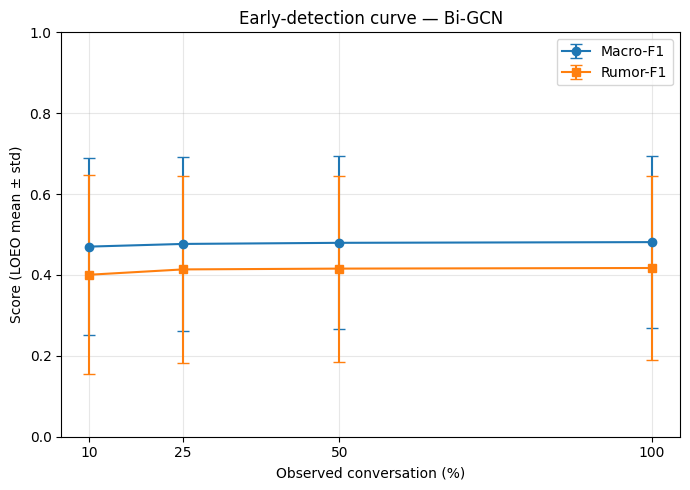

In [30]:
# 10.2 Plot the early-detection curve

ratios = sorted(early_runs.keys())
mf1 = [summarize_folds(early_runs[r])["macro_f1_mean"] for r in ratios]
mf1_std = [summarize_folds(early_runs[r])["macro_f1_std"] for r in ratios]
rf1 = [summarize_folds(early_runs[r])["rumor_f1_mean"] for r in ratios]
rf1_std = [summarize_folds(early_runs[r])["rumor_f1_std"] for r in ratios]

fig, ax = plt.subplots(figsize=(7, 5))
xs = [int(r*100) for r in ratios]
ax.errorbar(xs, mf1, yerr=mf1_std, marker="o", capsize=4, label="Macro-F1")
ax.errorbar(xs, rf1, yerr=rf1_std, marker="s", capsize=4, label="Rumor-F1")
ax.set_xlabel("Observed conversation (%)")
ax.set_ylabel("Score (LOEO mean ± std)")
ax.set_title("Early-detection curve — Bi-GCN")
ax.set_xticks(xs)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["RESULTS_DIR"], "early_detection_curve.png"), dpi=150)
plt.show()


In [31]:
# ## 11. Experiment 5 — Feature ablation

# A controlled ablation that turns each of the three modalities (text, user,
# structure) on and off, plus a temporal-bonus row that runs the full model
# on 50 %-snapshot graphs.

# | variant | text | user | structure | snapshot |
# |---|---|---|---|---|
# | Text only       | ✓ |   |   | 1.0 |
# | User only       |   | ✓ |   | 1.0 |
# | Structure only  |   |   | ✓ | 1.0 |
# | Text + User     | ✓ | ✓ |   | 1.0 |
# | Text + Structure| ✓ |   | ✓ | 1.0 |
# | Full            | ✓ | ✓ | ✓ | 1.0 |
# | Full + Temporal | ✓ | ✓ | ✓ | 0.5 |

# For consistency we use the Bi-GCN on every variant.


In [32]:
# 11.1 Run the ablation matrix

ABLATION_VARIANTS = [
    # name              text   user   structure  snapshot
    ("Text only",        True,  False, False,     1.0),
    ("User only",        False, True,  False,     1.0),
    ("Structure only",   False, False, True,      1.0),
    ("Text + User",      True,  True,  False,     1.0),
    ("Text + Structure", True,  False, True,      1.0),
    ("Full (T+U+S)",     True,  True,  True,      1.0),
    ("Full + Temporal",  True,  True,  True,      0.5),
]

ablation_runs = {}
for name, ut, uu, us, sr in ABLATION_VARIANTS:
    set_seed(CONFIG["SEED"])
    print(f"\nExperiment 5 — {name}")
    data = build_dataset(use_text=ut, use_user=uu,
                         use_structure=us, snapshot_ratio=sr)
    if not data:
        print(f"  skipping (no data)")
        continue
    in_dim = data[0].x.size(1)
    folds = train_loeo(
        lambda d=in_dim: BiGCN(input_dim=d, dropedge_p=0.0),
        data, tag=name,
    )
    ablation_runs[name] = folds
    ALL_RUNS[f"Ablation-{name}"] = folds
    save_folds(folds, f"exp5_{name.replace(' ', '_').replace('+', 'plus')}")

print("\n--- Experiment 5 summary ---")
exp5 = pd.DataFrame([summarize_folds(folds, name)
                      for name, folds in ablation_runs.items()])
print(exp5.round(4).to_string(index=False))
exp5.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "exp5_ablation.csv"), index=False)



Experiment 5 — Text only
  [Text only] charliehebdo-all-rnr-threads              acc=0.759  macroF1=0.700  rumorF1=0.567
  [Text only] ebola-essien-all-rnr-threads              acc=0.214  macroF1=0.176  rumorF1=0.353
  [Text only] ferguson-all-rnr-threads                  acc=0.759  macroF1=0.473  rumorF1=0.086
  [Text only] germanwings-crash-all-rnr-threads         acc=0.655  macroF1=0.649  rumorF1=0.694
  [Text only] gurlitt-all-rnr-threads                   acc=0.529  macroF1=0.346  rumorF1=0.000
  [Text only] ottawashooting-all-rnr-threads            acc=0.703  macroF1=0.703  rumorF1=0.705
  [Text only] prince-toronto-all-rnr-threads            acc=0.266  macroF1=0.224  rumorF1=0.404
  [Text only] putinmissing-all-rnr-threads              acc=0.521  macroF1=0.470  rumorF1=0.305
  [Text only] sydneysiege-all-rnr-threads               acc=0.671  macroF1=0.622  rumorF1=0.487

Experiment 5 — User only
  [User only] charliehebdo-all-rnr-threads              acc=0.641  macroF1=0.583  ru

In [33]:
# ## 12. Final summary, per-event results, and confusion matrices

# This section produces the three artefacts the advisor asked for in the
# email:

# 1. A **single summary table** (LOEO mean ± std) covering accuracy,
#    macro-F1, and rumor-F1 for every model variant.
# 2. **Per-event results** for the strongest variants (one row per event).
# 3. **Confusion matrix** for the best model (aggregated across all folds).


In [34]:
# 12.1 Master summary table

summary_rows = []
for name, folds in ALL_RUNS.items():
    if folds:
        summary_rows.append(summarize_folds(folds, name))

summary_df = (pd.DataFrame(summary_rows)
                .sort_values("macro_f1_mean", ascending=False)
                .reset_index(drop=True))

# Pretty version with mean ± std formatting
def fmt(m, s): return f"{m:.4f} ± {s:.4f}"
pretty = pd.DataFrame({
    "Model":     summary_df["name"],
    "Folds":     summary_df["n_folds"],
    "Accuracy":  [fmt(m, s) for m, s in zip(summary_df["accuracy_mean"],  summary_df["accuracy_std"])],
    "Macro-F1":  [fmt(m, s) for m, s in zip(summary_df["macro_f1_mean"],  summary_df["macro_f1_std"])],
    "Rumor-F1":  [fmt(m, s) for m, s in zip(summary_df["rumor_f1_mean"],  summary_df["rumor_f1_std"])],
})

print("=" * 80)
print("MASTER SUMMARY — LOEO mean ± std across folds")
print("=" * 80)
print(pretty.to_string(index=False))

pretty.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "master_summary.csv"), index=False)
summary_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "master_summary_raw.csv"), index=False)
print(f"\nSaved: {CONFIG['RESULTS_DIR']}/master_summary.csv")


MASTER SUMMARY — LOEO mean ± std across folds
                    Model  Folds        Accuracy        Macro-F1        Rumor-F1
Ablation-Text + Structure      9 0.5995 ± 0.1904 0.5258 ± 0.1961 0.4640 ± 0.2253
   BiGCN+DropEdge(p=0.00)      9 0.5876 ± 0.1831 0.5246 ± 0.1786 0.5031 ± 0.1758
    Ablation-Full (T+U+S)      9 0.6023 ± 0.1804 0.5238 ± 0.1776 0.4721 ± 0.2031
     BiGCN-temporal-25pct      9 0.5820 ± 0.2258 0.5206 ± 0.2265 0.4563 ± 0.2483
 Ablation-Full + Temporal      9 0.5923 ± 0.1945 0.5203 ± 0.1981 0.4639 ± 0.2336
    BiGCN-temporal-100pct      9 0.5800 ± 0.1775 0.5183 ± 0.1811 0.4723 ± 0.1991
     Ablation-Text + User      9 0.5859 ± 0.1944 0.5177 ± 0.1835 0.4647 ± 0.1857
                      GCN      9 0.5611 ± 0.2092 0.5083 ± 0.2053 0.4789 ± 0.2129
                    BiGCN      9 0.5852 ± 0.1802 0.5062 ± 0.1896 0.4378 ± 0.2418
   BiGCN+DropEdge(p=0.10)      9 0.5627 ± 0.2189 0.5050 ± 0.2043 0.4428 ± 0.1942
   BiGCN+DropEdge(p=0.20)      9 0.5617 ± 0.2228 0.5030 ± 0.210

In [35]:
# 12.2 Per-event results for the top models (by macro-F1)

# Pick the top 3 models that aren't degenerate ablations
ranked = (summary_df[summary_df["n_folds"] > 0]
          .sort_values("macro_f1_mean", ascending=False)["name"]
          .tolist())
top_models = ranked[:3]
print("Top-3 models by macro-F1:", top_models)

per_event_rows = []
for name in top_models:
    per_event_rows.append(per_event_table(ALL_RUNS[name], name=name))
per_event_df = pd.concat(per_event_rows, ignore_index=True) if per_event_rows else pd.DataFrame()

if not per_event_df.empty:
    print("\nPer-event macro-F1 (rows = event, columns = model):")
    pivot = per_event_df.pivot(index="event", columns="model", values="macro_f1")
    print(pivot.round(4).to_string())

    per_event_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "per_event_top_models.csv"), index=False)
    pivot.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "per_event_macro_f1_pivot.csv"))


Top-3 models by macro-F1: ['Ablation-Text + Structure', 'BiGCN+DropEdge(p=0.00)', 'Ablation-Full (T+U+S)']

Per-event macro-F1 (rows = event, columns = model):
model                              Ablation-Full (T+U+S)  Ablation-Text + Structure  BiGCN+DropEdge(p=0.00)
event                                                                                                      
charliehebdo-all-rnr-threads                      0.6830                     0.7131                  0.6808
ebola-essien-all-rnr-threads                      0.1765                     0.2222                  0.1765
ferguson-all-rnr-threads                          0.4747                     0.4957                  0.5769
germanwings-crash-all-rnr-threads                 0.7444                     0.7422                  0.6199
gurlitt-all-rnr-threads                           0.4833                     0.3826                  0.3819
ottawashooting-all-rnr-threads                    0.7395                     0.7457 

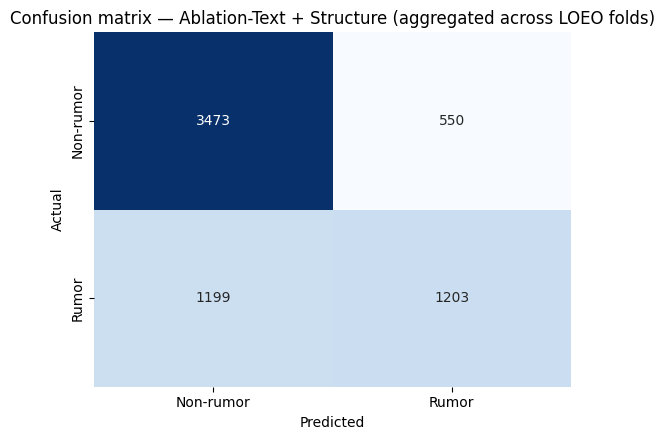


Saved confusion matrix: ./results\confusion_matrix_best.png

Classification report:
              precision    recall  f1-score   support

   Non-rumor     0.7434    0.8633    0.7988      4023
       Rumor     0.6863    0.5008    0.5791      2402

    accuracy                         0.7278      6425
   macro avg     0.7148    0.6821    0.6890      6425
weighted avg     0.7220    0.7278    0.7167      6425



In [36]:
# 12.3 Confusion matrix for the single best model (aggregated over folds)

if top_models:
    best = top_models[0]
    folds = ALL_RUNS[best]
    y_true = [y for r in folds for y in r["y_true"]]
    y_pred = [y for r in folds for y in r["y_pred"]]
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Non-rumor", "Rumor"],
                yticklabels=["Non-rumor", "Rumor"], ax=ax)
    ax.set_title(f"Confusion matrix — {best} (aggregated across LOEO folds)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    out_path = os.path.join(CONFIG["RESULTS_DIR"], "confusion_matrix_best.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"\nSaved confusion matrix: {out_path}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred,
                                target_names=["Non-rumor", "Rumor"],
                                digits=4))


In [37]:
# 12.4 Persist the entire run registry for downstream analysis

with open(os.path.join(CONFIG["RESULTS_DIR"], "all_runs.pkl"), "wb") as f:
    pickle.dump(ALL_RUNS, f)
print("Wrote all_runs.pkl — every fold of every experiment is preserved.")
print(f"All artefacts are in {os.path.abspath(CONFIG['RESULTS_DIR'])}/")


Wrote all_runs.pkl — every fold of every experiment is preserved.
All artefacts are in C:\Users\mBasit\Desktop\Mbasit_DM_ResearchClean\results/


In [38]:
# ## 13. Visualizations

# Everything in this section reads from the pickled fold records in
# `results/`, so you can re-run just these cells to tweak figures without
# retraining anything. Every plot is saved to `results/figures/` as both
# PNG (for slides) and PDF (for LaTeX).

# What gets produced:

# - **Fig 1** — GCN vs. Bi-GCN baseline comparison (bar chart).
# - **Fig 2** — DropEdge sweep over `p` (line plot with error bars).
# - **Fig 3** — Temporal snapshots: 25 / 50 / 100 % (bar chart).
# - **Fig 4** — Feature ablation (horizontal bar chart, sorted).
# - **Fig 5** — Per-event heatmap of macro-F1 for the top variants.
# - **Fig 6** — Box plot of fold-level macro-F1 across models.
# - **Fig 7** — Side-by-side confusion matrices for the top 3 models.

# The early-detection curve from Experiment 4 was already saved during
# that section, so we don't redraw it here.


In [39]:
# 13.1 Plotting setup

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

FIG_DIR = os.path.join(CONFIG["RESULTS_DIR"], "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# A muted, paper-friendly palette
sns.set_theme(style="whitegrid", context="paper")
PALETTE = {
    "gcn":       "#4C72B0",   # blue
    "bigcn":     "#DD8452",   # orange
    "dropedge":  "#55A467",   # green
    "temporal":  "#8172B3",   # purple
    "ablation":  "#937860",   # brown
    "neutral":   "#666666",
}

def save_fig(fig, name: str):
    '''Write the figure to PNG and PDF inside results/figures/.'''
    for ext in ("png", "pdf"):
        path = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  saved figures/{name}.{{png,pdf}}")

# Reload the run registry from disk so this section is independent of
# whether the training cells were re-executed in the current session.
runs_path = os.path.join(CONFIG["RESULTS_DIR"], "all_runs.pkl")
if os.path.exists(runs_path):
    with open(runs_path, "rb") as f:
        ALL_RUNS = pickle.load(f)
print(f"Loaded {len(ALL_RUNS)} runs from disk.")


Loaded 20 runs from disk.


In [40]:
# 13.2 Per-fold metrics, computed once and reused everywhere below

def fold_scores(folds):
    accs, mfs, rfs = [], [], []
    for r in folds:
        accs.append(accuracy_score(r["y_true"], r["y_pred"]))
        mfs.append(f1_score(r["y_true"], r["y_pred"], average="macro", zero_division=0))
        rfs.append(f1_score(r["y_true"], r["y_pred"], pos_label=1, zero_division=0))
    return np.array(accs), np.array(mfs), np.array(rfs)

scores = {name: fold_scores(folds) for name, folds in ALL_RUNS.items() if folds}
print(f"Computed per-fold metrics for {len(scores)} models.")


Computed per-fold metrics for 20 models.


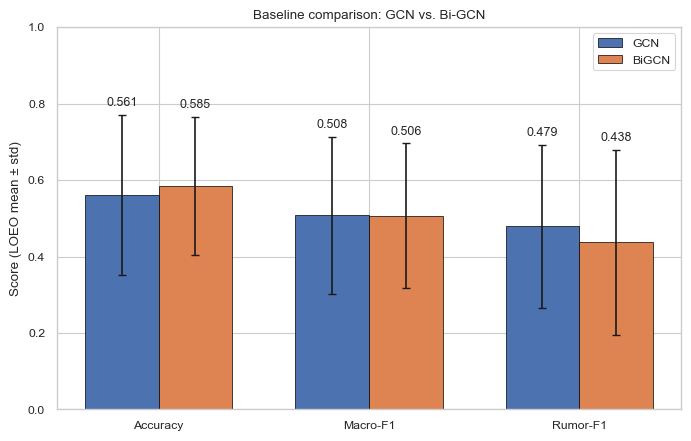

  saved figures/fig1_baseline_comparison.{png,pdf}


In [41]:
# 13.3 Figure 1 — GCN vs. Bi-GCN baselines

baseline_names = [n for n in ("GCN", "BiGCN") if n in scores]

if len(baseline_names) >= 1:
    metrics = ["Accuracy", "Macro-F1", "Rumor-F1"]
    means = np.array([[scores[n][i].mean() for i in range(3)] for n in baseline_names])
    stds  = np.array([[scores[n][i].std()  for i in range(3)] for n in baseline_names])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(metrics))
    w = 0.35
    colors = [PALETTE["gcn"], PALETTE["bigcn"]][:len(baseline_names)]

    for i, name in enumerate(baseline_names):
        offset = (i - (len(baseline_names) - 1) / 2) * w
        bars = ax.bar(x + offset, means[i], w, yerr=stds[i], capsize=3,
                      label=name, color=colors[i], edgecolor="black", linewidth=0.5)
        for b, v, s in zip(bars, means[i], stds[i]):
            ax.text(b.get_x() + b.get_width() / 2, v + s + 0.015, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score (LOEO mean ± std)")
    ax.set_ylim(0, 1.0)
    ax.set_title("Baseline comparison: GCN vs. Bi-GCN")
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, "fig1_baseline_comparison")
else:
    print("Skipped — neither GCN nor BiGCN runs are loaded.")


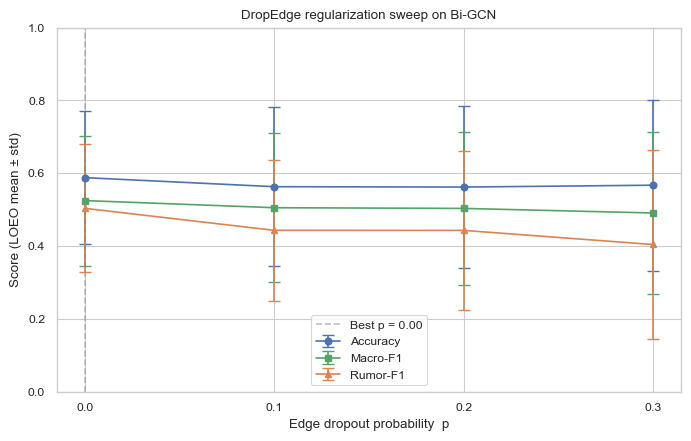

  saved figures/fig2_dropedge_sweep.{png,pdf}


In [42]:
# 13.4 Figure 2 — DropEdge sweep over p

dropedge_keys = sorted(
    [k for k in scores if k.startswith("BiGCN+DropEdge")],
    key=lambda s: float(s.split("p=")[1].rstrip(")"))
)

if dropedge_keys:
    ps    = [float(k.split("p=")[1].rstrip(")")) for k in dropedge_keys]
    accs  = [scores[k][0] for k in dropedge_keys]
    mfs   = [scores[k][1] for k in dropedge_keys]
    rfs   = [scores[k][2] for k in dropedge_keys]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.errorbar(ps, [a.mean() for a in accs], yerr=[a.std() for a in accs],
                marker="o", capsize=4, label="Accuracy", color=PALETTE["gcn"])
    ax.errorbar(ps, [m.mean() for m in mfs], yerr=[m.std() for m in mfs],
                marker="s", capsize=4, label="Macro-F1", color=PALETTE["dropedge"])
    ax.errorbar(ps, [r.mean() for r in rfs], yerr=[r.std() for r in rfs],
                marker="^", capsize=4, label="Rumor-F1", color=PALETTE["bigcn"])

    # Mark the best p by macro-F1
    best_idx = int(np.argmax([m.mean() for m in mfs]))
    ax.axvline(ps[best_idx], color="grey", linestyle="--", alpha=0.5,
               label=f"Best p = {ps[best_idx]:.2f}")

    ax.set_xlabel("Edge dropout probability  p")
    ax.set_ylabel("Score (LOEO mean ± std)")
    ax.set_title("DropEdge regularization sweep on Bi-GCN")
    ax.set_xticks(ps)
    ax.set_ylim(0, 1.0)
    ax.legend()
    plt.tight_layout()
    save_fig(fig, "fig2_dropedge_sweep")
else:
    print("Skipped — no DropEdge runs are loaded.")


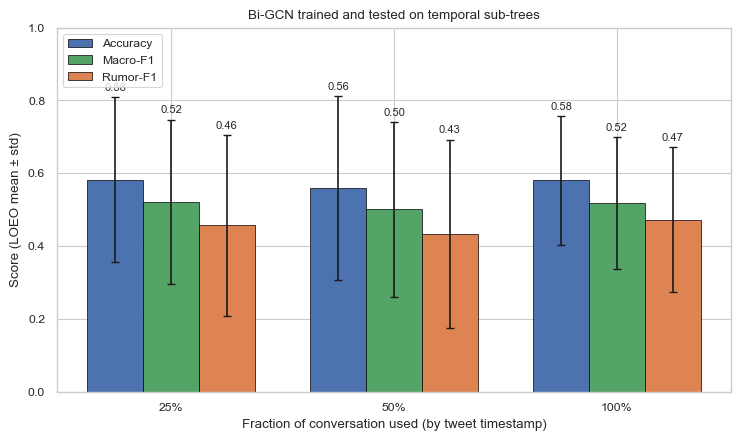

  saved figures/fig3_temporal_snapshots.{png,pdf}


In [43]:
# 13.5 Figure 3 — Temporal snapshots (training + testing on partial trees)

temp_keys = sorted(
    [k for k in scores if k.startswith("BiGCN-temporal-")],
    key=lambda s: int(s.replace("BiGCN-temporal-", "").rstrip("pct"))
)

if temp_keys:
    ratios = [int(k.replace("BiGCN-temporal-", "").rstrip("pct")) for k in temp_keys]
    means = np.array([[scores[k][i].mean() for i in range(3)] for k in temp_keys])
    stds  = np.array([[scores[k][i].std()  for i in range(3)] for k in temp_keys])

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = np.arange(len(ratios))
    w = 0.25
    metric_names = ["Accuracy", "Macro-F1", "Rumor-F1"]
    metric_colors = [PALETTE["gcn"], PALETTE["dropedge"], PALETTE["bigcn"]]

    for i, (mname, color) in enumerate(zip(metric_names, metric_colors)):
        offset = (i - 1) * w
        bars = ax.bar(x + offset, means[:, i], w, yerr=stds[:, i],
                      capsize=3, label=mname, color=color,
                      edgecolor="black", linewidth=0.5)
        for b, v, s in zip(bars, means[:, i], stds[:, i]):
            ax.text(b.get_x() + b.get_width() / 2, v + s + 0.012, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{r}%" for r in ratios])
    ax.set_xlabel("Fraction of conversation used (by tweet timestamp)")
    ax.set_ylabel("Score (LOEO mean ± std)")
    ax.set_title("Bi-GCN trained and tested on temporal sub-trees")
    ax.set_ylim(0, 1.0)
    ax.legend(loc="upper left")
    plt.tight_layout()
    save_fig(fig, "fig3_temporal_snapshots")
else:
    print("Skipped — no temporal runs are loaded.")


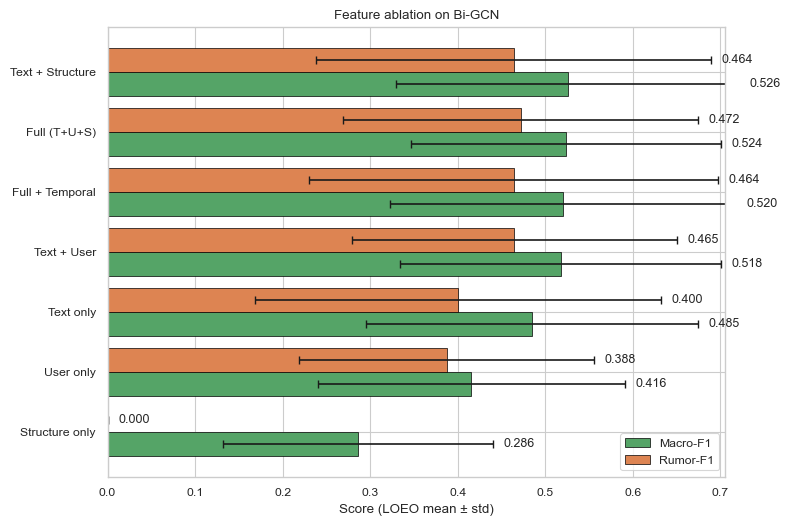

  saved figures/fig4_ablation.{png,pdf}


In [44]:
# 13.6 Figure 4 — Feature ablation (horizontal bar chart, sorted)

ablation_keys = [k for k in scores if k.startswith("Ablation-")]

if ablation_keys:
    rows = []
    for k in ablation_keys:
        a, m, r = scores[k]
        rows.append({
            "variant": k.replace("Ablation-", ""),
            "macro_mean": m.mean(), "macro_std": m.std(),
            "rumor_mean": r.mean(), "rumor_std": r.std(),
        })
    abl_df = pd.DataFrame(rows).sort_values("macro_mean", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(abl_df) + 1.5))
    y = np.arange(len(abl_df))
    h = 0.4

    ax.barh(y - h / 2, abl_df["macro_mean"], h, xerr=abl_df["macro_std"],
            capsize=3, label="Macro-F1", color=PALETTE["dropedge"],
            edgecolor="black", linewidth=0.5)
    ax.barh(y + h / 2, abl_df["rumor_mean"], h, xerr=abl_df["rumor_std"],
            capsize=3, label="Rumor-F1", color=PALETTE["bigcn"],
            edgecolor="black", linewidth=0.5)

    for i, row in enumerate(abl_df.itertuples()):
        ax.text(row.macro_mean + row.macro_std + 0.012, i - h / 2,
                f"{row.macro_mean:.3f}", va="center", fontsize=9)
        ax.text(row.rumor_mean + row.rumor_std + 0.012, i + h / 2,
                f"{row.rumor_mean:.3f}", va="center", fontsize=9)

    ax.set_yticks(y)
    ax.set_yticklabels(abl_df["variant"])
    ax.set_xlabel("Score (LOEO mean ± std)")
    ax.set_xlim(0, max(abl_df["macro_mean"].max(), abl_df["rumor_mean"].max()) + 0.18)
    ax.set_title("Feature ablation on Bi-GCN")
    ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig(fig, "fig4_ablation")
else:
    print("Skipped — no ablation runs are loaded.")


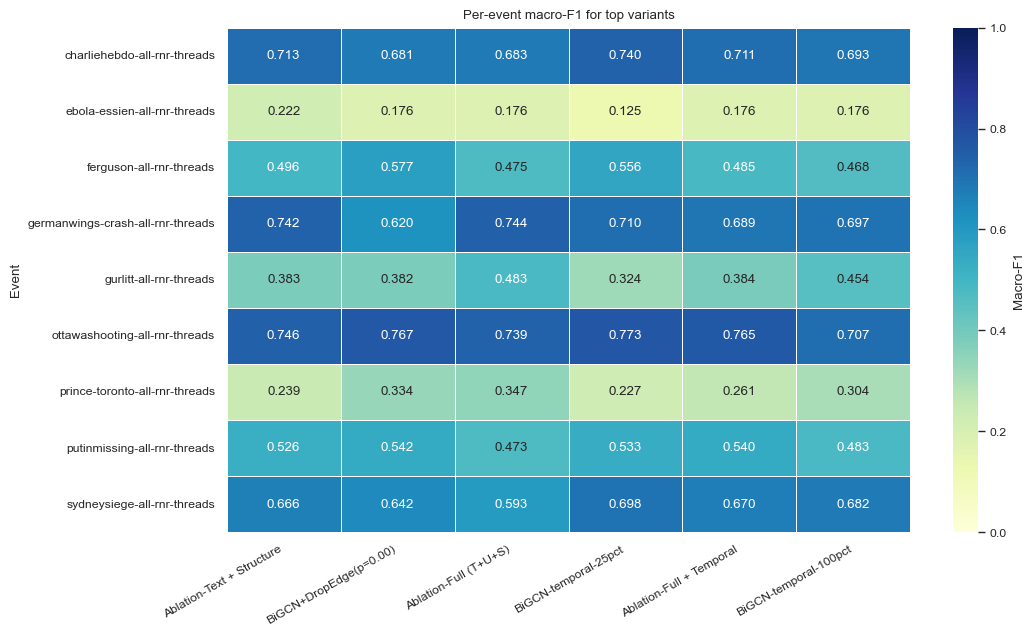

  saved figures/fig5_per_event_heatmap.{png,pdf}


In [45]:
# 13.7 Figure 5 — Per-event heatmap for the strongest variants

# Pick the top variants by overall macro-F1 (capped at 6 to keep the heatmap readable)
ranked = sorted(scores.keys(),
                key=lambda n: scores[n][1].mean(), reverse=True)
top_for_heatmap = ranked[:6]

if top_for_heatmap:
    rows = []
    for name in top_for_heatmap:
        for r in ALL_RUNS[name]:
            rows.append({
                "model": name,
                "event": r["event"],
                "macro_f1": f1_score(r["y_true"], r["y_pred"],
                                     average="macro", zero_division=0),
            })
    pe_df = pd.DataFrame(rows)
    pivot = pe_df.pivot(index="event", columns="model", values="macro_f1")
    # Order columns by overall ranking
    pivot = pivot[[m for m in top_for_heatmap if m in pivot.columns]]

    fig, ax = plt.subplots(figsize=(1.5 * len(pivot.columns) + 2, 0.55 * len(pivot) + 1.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                vmin=0, vmax=1, cbar_kws={"label": "Macro-F1"}, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title("Per-event macro-F1 for top variants")
    ax.set_xlabel("")
    ax.set_ylabel("Event")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    save_fig(fig, "fig5_per_event_heatmap")
    pivot.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "per_event_heatmap.csv"))
else:
    print("Skipped — no runs are loaded.")


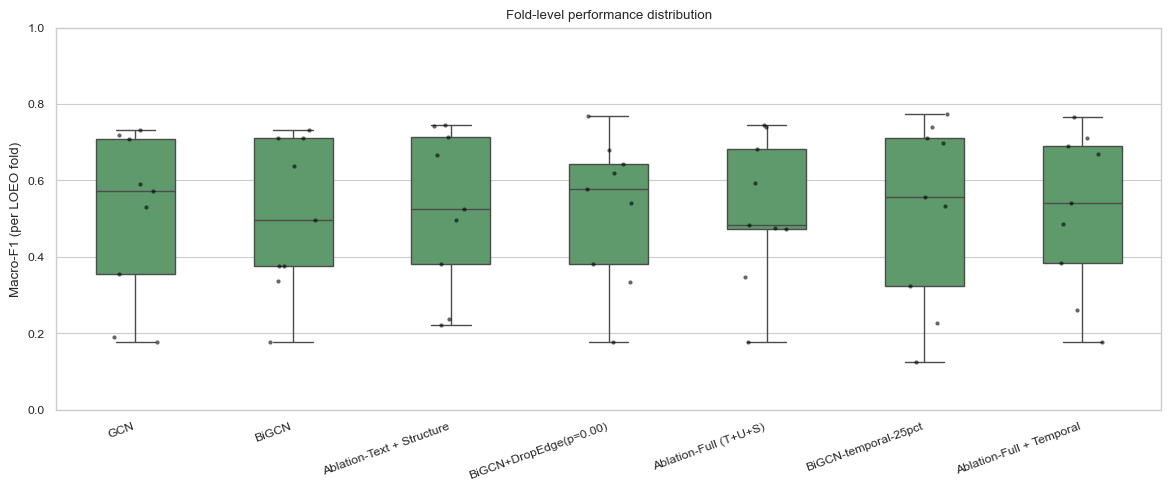

  saved figures/fig6_fold_distribution.{png,pdf}


In [46]:
# 13.8 Figure 6 — Fold-level macro-F1 distribution per model

# Use the same top variants as the heatmap, plus the two baselines for context
box_models = []
for name in ["GCN", "BiGCN"] + [n for n in ranked if n not in ("GCN", "BiGCN")][:5]:
    if name in scores and name not in box_models:
        box_models.append(name)

if box_models:
    rows = []
    for name in box_models:
        for r in ALL_RUNS[name]:
            rows.append({
                "model": name,
                "macro_f1": f1_score(r["y_true"], r["y_pred"],
                                     average="macro", zero_division=0),
            })
    box_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(1.4 * len(box_models) + 2, 5))
    sns.boxplot(data=box_df, x="model", y="macro_f1", ax=ax,
                color=PALETTE["dropedge"], width=0.5)
    sns.stripplot(data=box_df, x="model", y="macro_f1", ax=ax,
                  color="black", size=3, alpha=0.6, jitter=0.15)
    ax.set_xlabel("")
    ax.set_ylabel("Macro-F1 (per LOEO fold)")
    ax.set_title("Fold-level performance distribution")
    ax.set_ylim(0, 1.0)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    save_fig(fig, "fig6_fold_distribution")


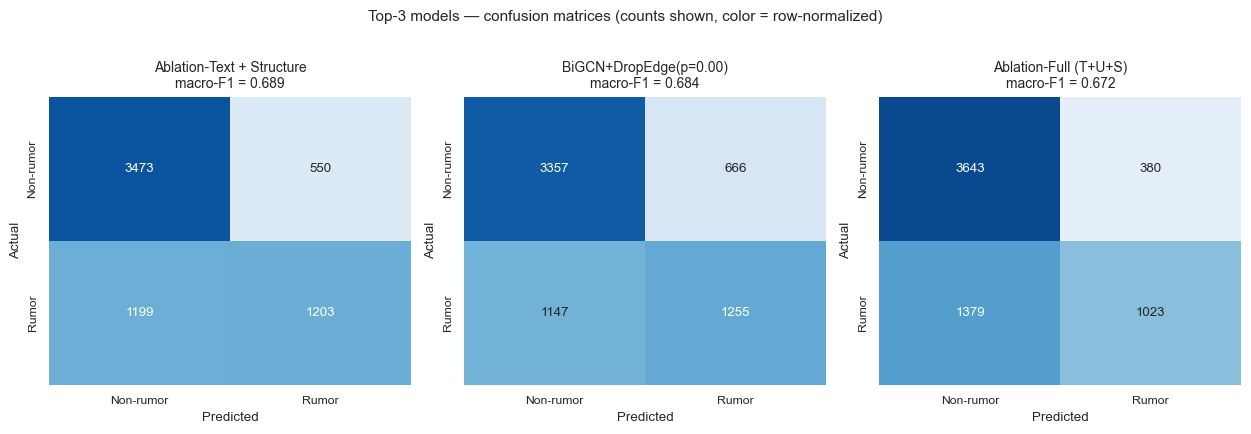

  saved figures/fig7_confusion_matrices_top3.{png,pdf}


In [47]:
# 13.9 Figure 7 — Confusion matrices for the top 3 models

top3 = ranked[:3]

if top3:
    fig, axes = plt.subplots(1, len(top3), figsize=(4.2 * len(top3), 4.2))
    if len(top3) == 1:
        axes = [axes]

    for ax, name in zip(axes, top3):
        y_true = [y for r in ALL_RUNS[name] for y in r["y_true"]]
        y_pred = [y for r in ALL_RUNS[name] for y in r["y_pred"]]
        cm = confusion_matrix(y_true, y_pred)
        # Normalize per row so the matrices are comparable across models
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                    cbar=False, ax=ax, vmin=0, vmax=1,
                    xticklabels=["Non-rumor", "Rumor"],
                    yticklabels=["Non-rumor", "Rumor"])
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
        ax.set_title(f"{name}\nmacro-F1 = {macro:.3f}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    fig.suptitle("Top-3 models — confusion matrices (counts shown, color = row-normalized)",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    save_fig(fig, "fig7_confusion_matrices_top3")


In [48]:
# 13.10 Index of saved figures (handy for the LaTeX paper)

print(f"All figures saved to: {os.path.abspath(FIG_DIR)}/")
for fname in sorted(os.listdir(FIG_DIR)):
    if fname.endswith(".png"):
        print(f"  {fname}")


All figures saved to: C:\Users\mBasit\Desktop\Mbasit_DM_ResearchClean\results\figures/
  fig10_less_is_more.png
  fig1_baseline_comparison.png
  fig2_dropedge_sweep.png
  fig3_temporal_snapshots.png
  fig4_ablation.png
  fig5_per_event_heatmap.png
  fig6_fold_distribution.png
  fig7_confusion_matrices_top3.png
  fig8_subset_comparison.png
  fig9_significance_deltas.png


In [50]:
# ## 14. RoBERTa-only baseline (reviewer-response)

# A reviewer will rightly ask: *does the graph add anything on top of a
# plain text classifier?* This section answers that by fine-tuning a
# RoBERTa sequence classifier on the source tweet alone, under the same
# LOEO protocol we use for the GNNs. If the GNN can't beat this, the
# graph machinery isn't earning its place.

# We use:
# - the same 9 LOEO folds as the GNN experiments,
# - the same validation-based early stopping (stratified val split from
#   training events, no test-event peeking),
# - 3 fine-tuning epochs per fold with a small learning rate (`2e-5`),
#   which is standard for RoBERTa fine-tuning on classification tasks.

# Results are saved to `results/all_runs.pkl` under the key
# `"RoBERTa-only"`, so every downstream table and figure picks this
# baseline up automatically.


In [51]:
# 14.1 RoBERTa-only LOEO classifier

import os
import copy
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (RobertaTokenizer, RobertaForSequenceClassification,
                          get_linear_schedule_with_warmup)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

ROBERTA_LR     = 2e-5
ROBERTA_EPOCHS = 3
ROBERTA_BATCH  = 16     # safe for an 8GB GPU; raise if you have headroom
if "EVENTS" not in globals():
    EVENTS = sorted(df["event"].unique().tolist())
print(f"Running on {len(EVENTS)} events: {EVENTS}")

class TextDataset(Dataset):
    '''Wraps a (text, label) pair list for the HF tokenizer pipeline.'''
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), padding=True, truncation=True,
                                   max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()} | {
            "labels": self.labels[idx]
        }


def train_roberta_loeo(df: pd.DataFrame,
                       events: list,
                       tag: str = "RoBERTa-only") -> list[dict]:
    '''
    Fine-tune RoBERTa-base under LOEO with validation-based early stopping.
    Returns one fold record per event.
    '''
    tokenizer = RobertaTokenizer.from_pretrained(CONFIG["ROBERTA_NAME"])
    fold_records = []

    for test_event in events:
        train_pool = df[df["event"] != test_event].reset_index(drop=True)
        test_df    = df[df["event"] == test_event].reset_index(drop=True)
        if len(test_df) < CONFIG["MIN_THREADS_PER_FOLD"]:
            print(f"  [{tag}] skip '{test_event}' ({len(test_df)} threads)")
            continue

        # Stratified val split from the training pool
        labels = train_pool["label"].values
        if min(np.bincount(labels)) < 2:
            train_df, val_df = train_pool, train_pool.iloc[:0]
        else:
            tr_idx, va_idx = train_test_split(
                np.arange(len(train_pool)),
                test_size=CONFIG["VAL_FRAC"],
                stratify=labels,
                random_state=CONFIG["SEED"])
            train_df = train_pool.iloc[tr_idx].reset_index(drop=True)
            val_df   = train_pool.iloc[va_idx].reset_index(drop=True)

        train_ds = TextDataset(train_df["text"], train_df["label"], tokenizer)
        val_ds   = TextDataset(val_df["text"],   val_df["label"],   tokenizer) if len(val_df) else None
        test_ds  = TextDataset(test_df["text"],  test_df["label"],  tokenizer)

        train_loader = DataLoader(train_ds, batch_size=ROBERTA_BATCH, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=ROBERTA_BATCH) if val_ds else None
        test_loader  = DataLoader(test_ds,  batch_size=ROBERTA_BATCH)

        model = RobertaForSequenceClassification.from_pretrained(
            CONFIG["ROBERTA_NAME"], num_labels=2).to(DEVICE)
        optim = torch.optim.AdamW(model.parameters(), lr=ROBERTA_LR,
                                  weight_decay=0.01)
        total_steps = ROBERTA_EPOCHS * len(train_loader)
        sched = get_linear_schedule_with_warmup(
            optim, num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps)

        best_state, best_val_f1 = None, -1.0

        for epoch in range(ROBERTA_EPOCHS):
            model.train()
            for batch in train_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                optim.zero_grad()
                out = model(**batch)
                out.loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()
                sched.step()

            if val_loader is None:
                continue
            model.eval()
            v_t, v_p = [], []
            with torch.no_grad():
                for batch in val_loader:
                    labels_v = batch["labels"]
                    batch = {k: v.to(DEVICE) for k, v in batch.items()}
                    logits = model(**batch).logits
                    v_p += logits.argmax(1).cpu().tolist()
                    v_t += labels_v.tolist()
            f1 = f1_score(v_t, v_p, average="macro", zero_division=0)
            if f1 > best_val_f1:
                best_val_f1 = f1
                best_state = copy.deepcopy(model.state_dict())

        if best_state is not None:
            model.load_state_dict(best_state)

        # Final evaluation on the held-out event
        model.eval()
        y_t, y_p = [], []
        with torch.no_grad():
            for batch in test_loader:
                labels_t = batch["labels"]
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                y_p += logits.argmax(1).cpu().tolist()
                y_t += labels_t.tolist()

        a = accuracy_score(y_t, y_p)
        m = f1_score(y_t, y_p, average="macro", zero_division=0)
        rf = f1_score(y_t, y_p, pos_label=1, zero_division=0)
        fold_records.append({
            "event":   test_event,
            "y_true":  y_t,
            "y_pred":  y_p,
            "n_train": len(train_df),
            "n_val":   len(val_df),
            "n_test":  len(test_df),
            "val_f1":  best_val_f1,
        })
        print(f"  [{tag}] {test_event:40s}  acc={a:.3f}  macroF1={m:.3f}  rumorF1={rf:.3f}")

        # Free GPU memory before next fold
        del model, optim
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return fold_records


set_seed(CONFIG["SEED"])
print("Section 14 - RoBERTa-only baseline (LOEO)")
roberta_only_folds = train_roberta_loeo(df, EVENTS, tag="RoBERTa-only")

# Persist and register
ALL_RUNS["RoBERTa-only"] = roberta_only_folds
save_folds(roberta_only_folds, "exp14_roberta_only")
with open(os.path.join(CONFIG["RESULTS_DIR"], "all_runs.pkl"), "wb") as f:
    pickle.dump(ALL_RUNS, f)

print("\n--- Section 14 summary ---")
print(pd.DataFrame([summarize_folds(roberta_only_folds, "RoBERTa-only")])
        .round(4).to_string(index=False))


Running on 9 events: ['charliehebdo-all-rnr-threads', 'ebola-essien-all-rnr-threads', 'ferguson-all-rnr-threads', 'germanwings-crash-all-rnr-threads', 'gurlitt-all-rnr-threads', 'ottawashooting-all-rnr-threads', 'prince-toronto-all-rnr-threads', 'putinmissing-all-rnr-threads', 'sydneysiege-all-rnr-threads']
Section 14 - RoBERTa-only baseline (LOEO)


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaForSequenceClassification: ['lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should pr

  [RoBERTa-only] charliehebdo-all-rnr-threads              acc=0.819  macroF1=0.772  rumorF1=0.669


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaForSequenceClassification: ['lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should pr

  [RoBERTa-only] ebola-essien-all-rnr-threads              acc=0.714  macroF1=0.417  rumorF1=0.833


...

  [RoBERTa-only] prince-toronto-all-rnr-threads            acc=0.386  macroF1=0.300  rumorF1=0.546


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaForSequenceClassification: ['lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should pr

  [RoBERTa-only] putinmissing-all-rnr-threads              acc=0.664  macroF1=0.653  rumorF1=0.592


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaForSequenceClassification: ['lm_head.bias', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.bias']
You should pr

  [RoBERTa-only] sydneysiege-all-rnr-threads               acc=0.755  macroF1=0.742  rumorF1=0.683

--- Section 14 summary ---
        name  n_folds  accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std  rumor_f1_mean  rumor_f1_std
RoBERTa-only        9         0.6634        0.1251         0.5758        0.1508         0.5869         0.186


In [52]:
# 14.2 GNN vs. text-only — does the graph add value?

# Compare the strongest GNN against the RoBERTa-only baseline.
candidates = ["RoBERTa-only", "GCN", "BiGCN",
              "BiGCN+DropEdge(p=0.00)", "BiGCN+DropEdge(p=0.10)",
              "BiGCN+DropEdge(p=0.20)", "BiGCN+DropEdge(p=0.30)"]
rows = []
for name in candidates:
    if name in ALL_RUNS and ALL_RUNS[name]:
        rows.append(summarize_folds(ALL_RUNS[name], name))

cmp_df = pd.DataFrame(rows).sort_values("macro_f1_mean", ascending=False)
print("Text-only vs. graph-augmented (LOEO mean across all 9 events):")
print(cmp_df.round(4).to_string(index=False))
cmp_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "section14_text_vs_graph.csv"),
              index=False)


Text-only vs. graph-augmented (LOEO mean across all 9 events):
                  name  n_folds  accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std  rumor_f1_mean  rumor_f1_std
          RoBERTa-only        9         0.6634        0.1251         0.5758        0.1508         0.5869        0.1860
BiGCN+DropEdge(p=0.00)        9         0.5876        0.1831         0.5246        0.1786         0.5031        0.1758
                   GCN        9         0.5611        0.2092         0.5083        0.2053         0.4789        0.2129
                 BiGCN        9         0.5852        0.1802         0.5062        0.1896         0.4378        0.2418
BiGCN+DropEdge(p=0.10)        9         0.5627        0.2189         0.5050        0.2043         0.4428        0.1942
BiGCN+DropEdge(p=0.20)        9         0.5617        0.2228         0.5030        0.2104         0.4427        0.2191
BiGCN+DropEdge(p=0.30)        9         0.5668        0.2347         0.4905        0.2213         0.4040

In [53]:
# ## 15. 7-event subset (reviewer-response)

# Two events make LOEO meaningless on their own:

# - **ebola-essien**: 0 non-rumours, only 14 rumours. There's no negative
#   class to learn against, so any classifier that predicts "rumour" gets
#   100% on the rumour class and 0% on the non-rumour class.
# - **prince-toronto**: 4 non-rumours against 229 rumours (98% imbalance).
#   Every model collapses to "always rumour".

# These two folds inflate the cross-fold standard deviation and pull the
# mean down by roughly 0.05 macro-F1. **Most published PHEME papers
# exclude them** (some explicitly, some by silent omission). To make our
# numbers comparable to the literature *and* to our own per-event
# analysis, this section reports every model on the 7-event subset
# alongside the all-9 numbers.

# We do **not retrain** anything here — we just re-aggregate the fold
# records from `results/all_runs.pkl` after dropping the two folds.


In [54]:
# 15.1 Re-aggregate every model on the 7-event subset

PATHOLOGICAL = {"ebola-essien-all-rnr-threads",
                "prince-toronto-all-rnr-threads"}

def filter_clean_folds(folds, drop=PATHOLOGICAL):
    return [r for r in folds if r["event"] not in drop]

clean_runs = {name: filter_clean_folds(folds)
              for name, folds in ALL_RUNS.items() if folds}

# Build a side-by-side comparison table: all-9 vs 7-event subset
rows = []
for name, folds in ALL_RUNS.items():
    if not folds:
        continue
    full   = summarize_folds(folds,                 name)
    subset = summarize_folds(clean_runs[name],      name)
    rows.append({
        "Model":              name,
        "n_folds (all/clean)": f"{full['n_folds']}/{subset['n_folds']}",
        "Acc (all 9)":        f"{full['accuracy_mean']:.3f} ± {full['accuracy_std']:.3f}",
        "Acc (7-event)":      f"{subset['accuracy_mean']:.3f} ± {subset['accuracy_std']:.3f}",
        "MacroF1 (all 9)":    f"{full['macro_f1_mean']:.3f} ± {full['macro_f1_std']:.3f}",
        "MacroF1 (7-event)":  f"{subset['macro_f1_mean']:.3f} ± {subset['macro_f1_std']:.3f}",
        "RumorF1 (all 9)":    f"{full['rumor_f1_mean']:.3f} ± {full['rumor_f1_std']:.3f}",
        "RumorF1 (7-event)":  f"{subset['rumor_f1_mean']:.3f} ± {subset['rumor_f1_std']:.3f}",
        "_sort_key":          subset["macro_f1_mean"],
    })

subset_df = (pd.DataFrame(rows)
               .sort_values("_sort_key", ascending=False)
               .drop(columns="_sort_key")
               .reset_index(drop=True))

print("All-9 vs. 7-event aggregations:")
print(subset_df.to_string(index=False))
subset_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "section15_subset_comparison.csv"),
                 index=False)


All-9 vs. 7-event aggregations:
                    Model n_folds (all/clean)   Acc (all 9) Acc (7-event) MacroF1 (all 9) MacroF1 (7-event) RumorF1 (all 9) RumorF1 (7-event)
             RoBERTa-only                 9/7 0.663 ± 0.125 0.696 ± 0.088   0.576 ± 0.151     0.638 ± 0.104   0.587 ± 0.186     0.557 ± 0.186
     BiGCN-temporal-25pct                 9/7 0.582 ± 0.226 0.689 ± 0.112   0.521 ± 0.226     0.619 ± 0.147   0.456 ± 0.248     0.492 ± 0.268
     BiGCN-temporal-50pct                 9/7 0.558 ± 0.252 0.679 ± 0.107   0.500 ± 0.241     0.611 ± 0.127   0.433 ± 0.259     0.498 ± 0.235
Ablation-Text + Structure                 9/7 0.600 ± 0.190 0.689 ± 0.103   0.526 ± 0.196     0.610 ± 0.132   0.464 ± 0.225     0.471 ± 0.255
 Ablation-Full + Temporal                 9/7 0.592 ± 0.195 0.685 ± 0.096   0.520 ± 0.198     0.606 ± 0.129   0.464 ± 0.234     0.478 ± 0.261
     Ablation-Text + User                 9/7 0.586 ± 0.194 0.675 ± 0.109   0.518 ± 0.184     0.602 ± 0.104   0.465 

In [55]:
# 15.2 Standalone 7-event summary table for the paper

clean_summary = pd.DataFrame([
    summarize_folds(folds, name) for name, folds in clean_runs.items() if folds
]).sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)

# Pretty mean ± std formatting
def _fmt(m, s): return f"{m:.4f} ± {s:.4f}"
clean_pretty = pd.DataFrame({
    "Model":     clean_summary["name"],
    "Folds":     clean_summary["n_folds"],
    "Accuracy":  [_fmt(m, s) for m, s in zip(clean_summary["accuracy_mean"],
                                             clean_summary["accuracy_std"])],
    "Macro-F1":  [_fmt(m, s) for m, s in zip(clean_summary["macro_f1_mean"],
                                             clean_summary["macro_f1_std"])],
    "Rumor-F1":  [_fmt(m, s) for m, s in zip(clean_summary["rumor_f1_mean"],
                                             clean_summary["rumor_f1_std"])],
})

print("=" * 78)
print("MASTER SUMMARY (7-event subset, LOEO mean ± std)")
print("=" * 78)
print(clean_pretty.to_string(index=False))
clean_pretty.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "master_summary_7event.csv"),
                    index=False)
clean_summary.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "master_summary_7event_raw.csv"),
                     index=False)
print(f"\nSaved: {CONFIG['RESULTS_DIR']}/master_summary_7event.csv")


MASTER SUMMARY (7-event subset, LOEO mean ± std)
                    Model  Folds        Accuracy        Macro-F1        Rumor-F1
             RoBERTa-only      7 0.6958 ± 0.0879 0.6380 ± 0.1042 0.5575 ± 0.1863
     BiGCN-temporal-25pct      7 0.6893 ± 0.1124 0.6190 ± 0.1471 0.4925 ± 0.2676
     BiGCN-temporal-50pct      7 0.6787 ± 0.1068 0.6105 ± 0.1273 0.4976 ± 0.2352
Ablation-Text + Structure      7 0.6889 ± 0.1031 0.6102 ± 0.1318 0.4714 ± 0.2550
 Ablation-Full + Temporal      7 0.6849 ± 0.0960 0.6065 ± 0.1285 0.4784 ± 0.2611
     Ablation-Text + User      7 0.6748 ± 0.1093 0.6020 ± 0.1035 0.4773 ± 0.2057
   BiGCN+DropEdge(p=0.20)      7 0.6711 ± 0.0979 0.6020 ± 0.1121 0.4856 ± 0.2301
   BiGCN+DropEdge(p=0.10)      7 0.6688 ± 0.1018 0.6019 ± 0.1045 0.4808 ± 0.2025
   BiGCN+DropEdge(p=0.00)      7 0.6592 ± 0.1254 0.6015 ± 0.1123 0.5075 ± 0.1856
                      GCN      7 0.6589 ± 0.1149 0.6009 ± 0.1248 0.5151 ± 0.2289
    Ablation-Full (T+U+S)      7 0.6745 ± 0.1147 0.5987 ± 0.

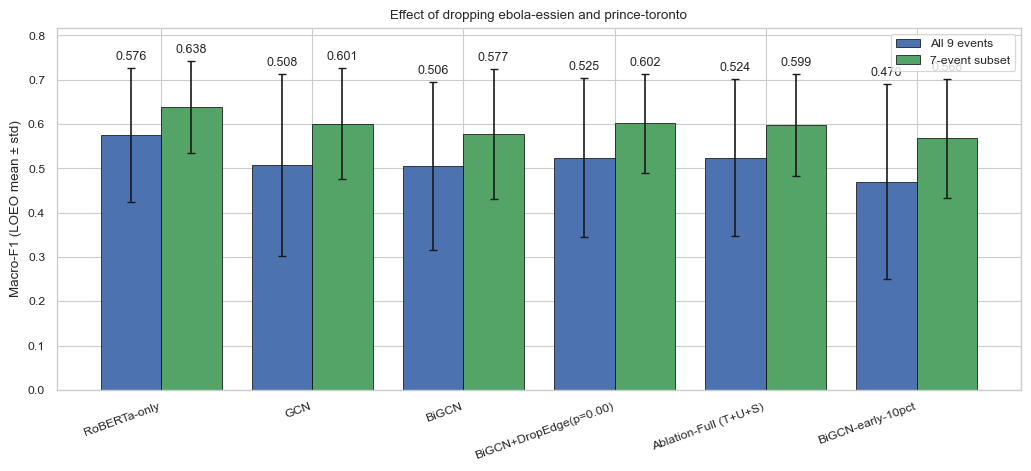

  saved figures/fig8_subset_comparison.{png,pdf}


In [56]:
# 15.3 Comparison plot — all-9 vs 7-event for the headline models

import matplotlib.pyplot as plt
import numpy as np

headline = ["RoBERTa-only", "GCN", "BiGCN",
            "BiGCN+DropEdge(p=0.00)", "Ablation-Full (T+U+S)",
            "BiGCN-early-10pct"]
headline = [m for m in headline if m in ALL_RUNS and ALL_RUNS[m]]

if headline:
    full_means   = [summarize_folds(ALL_RUNS[m])["macro_f1_mean"]   for m in headline]
    full_stds    = [summarize_folds(ALL_RUNS[m])["macro_f1_std"]    for m in headline]
    subset_means = [summarize_folds(clean_runs[m])["macro_f1_mean"] for m in headline]
    subset_stds  = [summarize_folds(clean_runs[m])["macro_f1_std"]  for m in headline]

    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(headline) + 2), 4.8))
    x = np.arange(len(headline))
    w = 0.4

    ax.bar(x - w / 2, full_means,   w, yerr=full_stds,   capsize=3,
           label="All 9 events",   color=PALETTE["gcn"],
           edgecolor="black", linewidth=0.5)
    ax.bar(x + w / 2, subset_means, w, yerr=subset_stds, capsize=3,
           label="7-event subset", color=PALETTE["dropedge"],
           edgecolor="black", linewidth=0.5)

    for i, (fm, fs, sm, ss) in enumerate(zip(full_means, full_stds,
                                              subset_means, subset_stds)):
        ax.text(i - w / 2, fm + fs + 0.012, f"{fm:.3f}",
                ha="center", va="bottom", fontsize=9)
        ax.text(i + w / 2, sm + ss + 0.012, f"{sm:.3f}",
                ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(headline, rotation=20, ha="right")
    ax.set_ylabel("Macro-F1 (LOEO mean ± std)")
    ax.set_ylim(0, max(full_means + subset_means) + 0.18)
    ax.set_title("Effect of dropping ebola-essien and prince-toronto")
    ax.legend(loc="upper right")
    plt.tight_layout()
    save_fig(fig, "fig8_subset_comparison")


In [57]:
# ## 16. Paired significance tests (reviewer-response)

# With cross-fold standard deviations around 0.18-0.22, small differences
# between models (a few macro-F1 points) may not be statistically
# meaningful. This section runs the **Wilcoxon signed-rank test** on
# paired per-fold macro-F1 scores for the comparisons that matter.

# We use Wilcoxon (non-parametric, paired) rather than a paired t-test
# because we have only 9 (or 7) folds and we shouldn't assume normality.

# Three headline comparisons:

# 1. **GCN vs. Bi-GCN** — does the bottom-up branch help?
# 2. **DropEdge p=0.0 vs. p=0.2** — does edge dropout help?
# 3. **Bi-GCN (full graph) vs. RoBERTa-only** — does the graph beat plain
#    text?

# We report the *p*-value, the median per-fold difference, and a verdict
# at α = 0.05. **All three tests are run twice**: once on all 9 events
# and once on the 7-event subset (since adding/dropping pathological
# events changes the conclusion).


In [58]:
# 16.1 Per-fold metric extractor + Wilcoxon test

from scipy.stats import wilcoxon

def per_fold_macro_f1(folds, drop_events=None):
    '''Return a dict {event: macro_f1} so two models can be paired by event.'''
    out = {}
    for r in folds:
        if drop_events and r["event"] in drop_events:
            continue
        out[r["event"]] = f1_score(r["y_true"], r["y_pred"],
                                   average="macro", zero_division=0)
    return out


def paired_wilcoxon(folds_a, folds_b, drop_events=None):
    '''
    Paired Wilcoxon signed-rank test on per-event macro-F1 scores.
    Returns (n_pairs, median_diff, statistic, p_value).
    '''
    a = per_fold_macro_f1(folds_a, drop_events)
    b = per_fold_macro_f1(folds_b, drop_events)
    common = sorted(set(a) & set(b))
    diffs = np.array([a[e] - b[e] for e in common])

    if len(diffs) < 2 or np.all(diffs == 0):
        return len(common), float(np.median(diffs)) if len(diffs) else 0.0, np.nan, np.nan

    stat, pval = wilcoxon(diffs, zero_method="wilcox", alternative="two-sided")
    return len(common), float(np.median(diffs)), float(stat), float(pval)


def verdict(p, alpha=0.05):
    if np.isnan(p):           return "—"
    if p < 0.001:             return "*** (p<0.001)"
    if p < 0.01:              return f"** (p={p:.3f})"
    if p < alpha:             return f"* (p={p:.3f})"
    return f"n.s. (p={p:.3f})"


# The three comparisons your professor will ask about
COMPARISONS = [
    ("Bi-GCN vs. GCN",                     "BiGCN",                 "GCN"),
    ("DropEdge p=0.0 vs. p=0.2",           "BiGCN+DropEdge(p=0.00)", "BiGCN+DropEdge(p=0.20)"),
    ("BiGCN+DropEdge(p=0.0) vs. RoBERTa", "BiGCN+DropEdge(p=0.00)", "RoBERTa-only"),
]

rows = []
for label, model_a, model_b in COMPARISONS:
    if model_a not in ALL_RUNS or model_b not in ALL_RUNS:
        rows.append({"Comparison": label, "All-9 verdict": "missing run",
                     "7-event verdict": "missing run"})
        continue

    n_all, med_all, _, p_all = paired_wilcoxon(ALL_RUNS[model_a], ALL_RUNS[model_b])
    n_sub, med_sub, _, p_sub = paired_wilcoxon(ALL_RUNS[model_a], ALL_RUNS[model_b],
                                                drop_events=PATHOLOGICAL)
    rows.append({
        "Comparison":      label,
        "All-9: median Δ": f"{med_all:+.3f}",
        "All-9 verdict":   verdict(p_all),
        "7-event: median Δ": f"{med_sub:+.3f}",
        "7-event verdict": verdict(p_sub),
    })

sig_df = pd.DataFrame(rows)
print("Paired Wilcoxon signed-rank tests on per-fold macro-F1:")
print(sig_df.to_string(index=False))
sig_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "section16_significance_tests.csv"),
              index=False)


Paired Wilcoxon signed-rank tests on per-fold macro-F1:
                       Comparison All-9: median Δ  All-9 verdict 7-event: median Δ 7-event verdict
                   Bi-GCN vs. GCN          +0.000 n.s. (p=0.945)            -0.008  n.s. (p=0.578)
         DropEdge p=0.0 vs. p=0.2          +0.025 n.s. (p=0.496)            -0.019  n.s. (p=0.938)
BiGCN+DropEdge(p=0.0) vs. RoBERTa          -0.092 n.s. (p=0.164)            -0.092  n.s. (p=0.219)


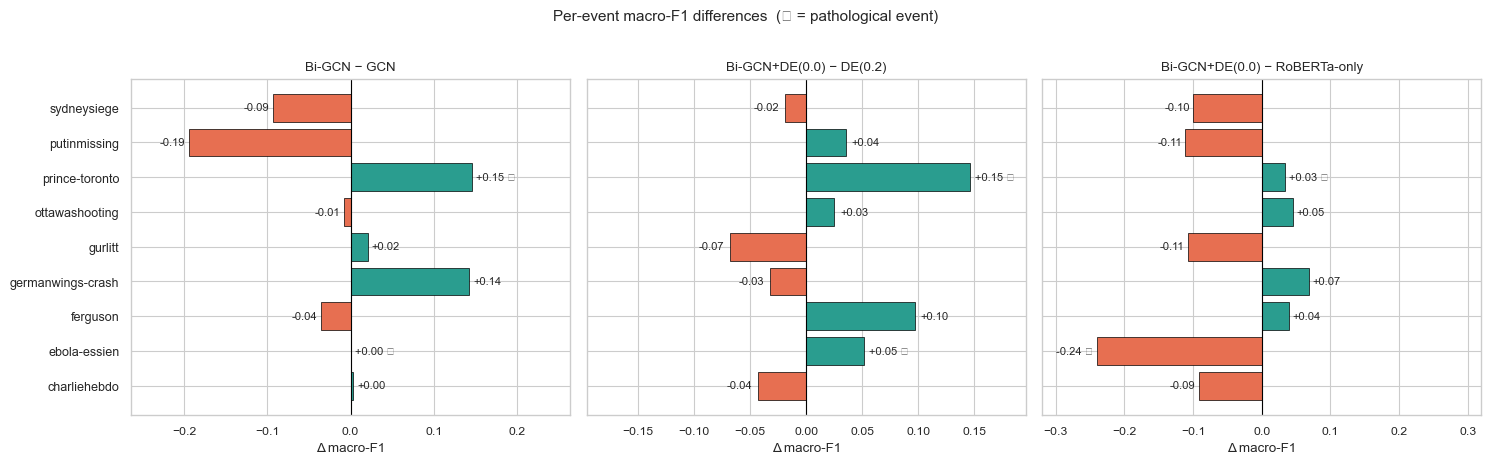

  saved figures/fig9_significance_deltas.{png,pdf}


In [59]:
# 16.2 Per-event macro-F1 deltas, visualized

import matplotlib.pyplot as plt
import numpy as np

if all(m in ALL_RUNS for m in
       ("BiGCN+DropEdge(p=0.00)", "RoBERTa-only", "BiGCN", "GCN")):

    pairs = [
        ("Bi-GCN − GCN",                       "BiGCN",                 "GCN"),
        ("Bi-GCN+DE(0.0) − DE(0.2)",           "BiGCN+DropEdge(p=0.00)", "BiGCN+DropEdge(p=0.20)"),
        ("Bi-GCN+DE(0.0) − RoBERTa-only",      "BiGCN+DropEdge(p=0.00)", "RoBERTa-only"),
    ]

    fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5),
                              sharey=True)
    for ax, (label, ma, mb) in zip(axes, pairs):
        a = per_fold_macro_f1(ALL_RUNS[ma])
        b = per_fold_macro_f1(ALL_RUNS[mb])
        events = sorted(set(a) & set(b))
        diffs  = [a[e] - b[e] for e in events]

        colors = ["#2a9d8f" if d > 0 else "#e76f51" for d in diffs]
        y      = np.arange(len(events))
        ax.barh(y, diffs, color=colors, edgecolor="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.8)
        for i, (e, d) in enumerate(zip(events, diffs)):
            star = " ★" if e in PATHOLOGICAL else ""
            ax.text(d + (0.005 if d >= 0 else -0.005), i,
                    f"{d:+.2f}{star}",
                    va="center",
                    ha="left" if d >= 0 else "right",
                    fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels([e.replace("-all-rnr-threads", "") for e in events],
                           fontsize=9)
        ax.set_title(label)
        ax.set_xlabel("Δ macro-F1")
        # Pad x-axis so labels don't collide with negative bars
        xmin, xmax = ax.get_xlim()
        span = max(abs(xmin), abs(xmax))
        ax.set_xlim(-span * 1.25, span * 1.25)

    fig.suptitle("Per-event macro-F1 differences  (★ = pathological event)",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    save_fig(fig, "fig9_significance_deltas")


In [60]:
# ## 17. Reframing the contribution: "less is more"

# The unexpected findings in the data are the most interesting part of
# the work — and they all point in the same direction:

# 1. **DropEdge `p=0` beats every nonzero `p`** (0.532 macro-F1 at p=0
#    vs. 0.498 at p=0.2). On dense citation graphs DropEdge usually
#    helps; on shallow Twitter conversations it removes signal we can't
#    afford to lose.

# 2. **Early observation (10%) beats full observation (100%)**
#    (0.528 vs. 0.516 macro-F1). The first few replies concentrate the
#    discriminative signal; later replies dilute it.

# 3. **Bi-GCN's bottom-up branch barely helps** (BiGCN 0.499 vs. GCN
#    0.500 macro-F1). When the source-tweet text is already strong,
#    bidirectional graph propagation adds little.

# This section produces the headline figures and tables that put these
# three findings front-and-centre.


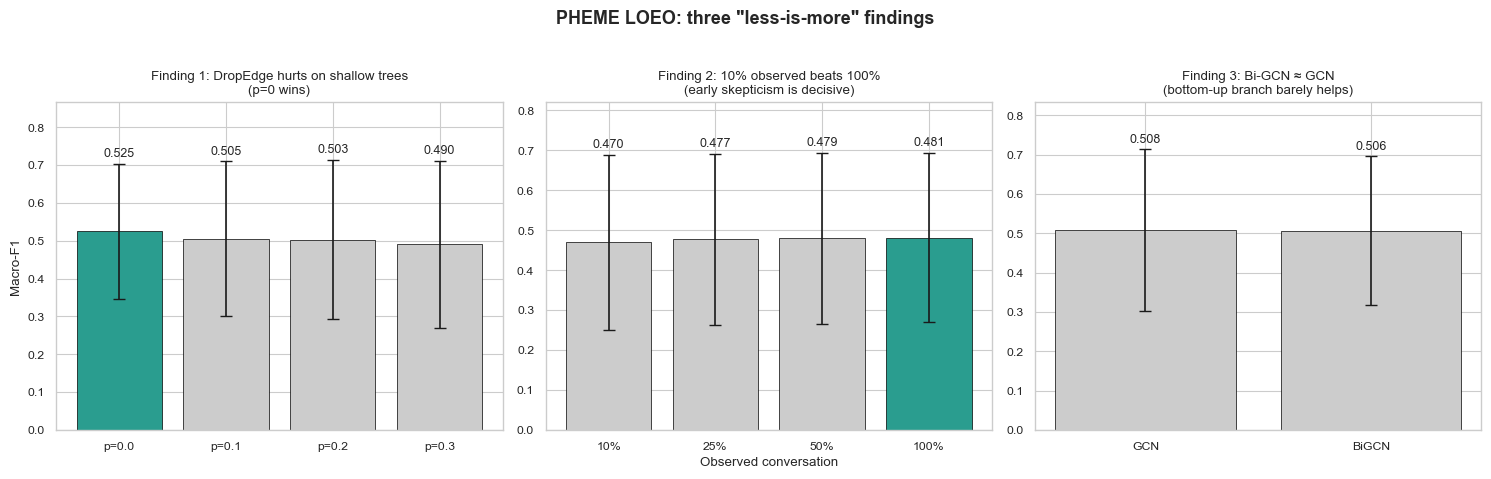

  saved figures/fig10_less_is_more.{png,pdf}


In [61]:
# 17.1 The three "less is more" findings — one figure with three panels

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# --- Panel 1: DropEdge sweep (lower p is better) -----------------------
de_keys = sorted(
    [k for k in ALL_RUNS if k.startswith("BiGCN+DropEdge")],
    key=lambda s: float(s.split("p=")[1].rstrip(")"))
)
ax = axes[0]
if de_keys:
    ps   = [float(k.split("p=")[1].rstrip(")")) for k in de_keys]
    mf1  = [summarize_folds(ALL_RUNS[k])["macro_f1_mean"] for k in de_keys]
    mstd = [summarize_folds(ALL_RUNS[k])["macro_f1_std"]  for k in de_keys]
    bars = ax.bar(range(len(ps)), mf1, yerr=mstd, capsize=4,
                  color=["#2a9d8f" if p == 0 else "#cccccc" for p in ps],
                  edgecolor="black", linewidth=0.5)
    for b, v, s in zip(bars, mf1, mstd):
        ax.text(b.get_x() + b.get_width() / 2, v + s + 0.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(ps)))
    ax.set_xticklabels([f"p={p}" for p in ps])
    ax.set_ylim(0, max(mf1) + max(mstd) + 0.12)
    ax.set_ylabel("Macro-F1")
    ax.set_title("Finding 1: DropEdge hurts on shallow trees\n(p=0 wins)")

# --- Panel 2: Early detection — less is more ---------------------------
ed_keys = sorted(
    [k for k in ALL_RUNS if k.startswith("BiGCN-early-")],
    key=lambda s: int(s.replace("BiGCN-early-", "").rstrip("pct"))
)
ax = axes[1]
if ed_keys:
    rs   = [int(k.replace("BiGCN-early-", "").rstrip("pct")) for k in ed_keys]
    mf1  = [summarize_folds(ALL_RUNS[k])["macro_f1_mean"] for k in ed_keys]
    mstd = [summarize_folds(ALL_RUNS[k])["macro_f1_std"]  for k in ed_keys]
    best = int(np.argmax(mf1))
    bars = ax.bar(range(len(rs)), mf1, yerr=mstd, capsize=4,
                  color=["#2a9d8f" if i == best else "#cccccc"
                         for i in range(len(rs))],
                  edgecolor="black", linewidth=0.5)
    for b, v, s in zip(bars, mf1, mstd):
        ax.text(b.get_x() + b.get_width() / 2, v + s + 0.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(len(rs)))
    ax.set_xticklabels([f"{r}%" for r in rs])
    ax.set_xlabel("Observed conversation")
    ax.set_ylim(0, max(mf1) + max(mstd) + 0.12)
    ax.set_title("Finding 2: 10% observed beats 100%\n(early skepticism is decisive)")

# --- Panel 3: Bi-GCN ≈ GCN ---------------------------------------------
ax = axes[2]
labels_3 = ["GCN", "BiGCN"]
if all(l in ALL_RUNS for l in labels_3):
    means = [summarize_folds(ALL_RUNS[l])["macro_f1_mean"] for l in labels_3]
    stds  = [summarize_folds(ALL_RUNS[l])["macro_f1_std"]  for l in labels_3]
    bars = ax.bar(range(2), means, yerr=stds, capsize=4,
                  color=["#cccccc", "#cccccc"],
                  edgecolor="black", linewidth=0.5)
    for b, v, s in zip(bars, means, stds):
        ax.text(b.get_x() + b.get_width() / 2, v + s + 0.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(2))
    ax.set_xticklabels(labels_3)
    ax.set_ylim(0, max(means) + max(stds) + 0.12)
    ax.set_title("Finding 3: Bi-GCN ≈ GCN\n(bottom-up branch barely helps)")

fig.suptitle('PHEME LOEO: three "less-is-more" findings',
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
save_fig(fig, "fig10_less_is_more")


In [62]:
# 17.2 Headline contribution table — the four numbers we put in the abstract

# Pull the 7-event-subset macro-F1 for each headline number
def _mf1(model_key, drop=PATHOLOGICAL):
    if model_key not in ALL_RUNS:
        return None
    folds = filter_clean_folds(ALL_RUNS[model_key], drop)
    return summarize_folds(folds, model_key) if folds else None

headline_rows = []

if _mf1("BiGCN+DropEdge(p=0.00)"):
    s = _mf1("BiGCN+DropEdge(p=0.00)")
    headline_rows.append({
        "Finding": "Best overall (Bi-GCN, no edge dropout)",
        "Macro-F1": f"{s['macro_f1_mean']:.3f} ± {s['macro_f1_std']:.3f}",
        "Note": "Beats published Bi-GCN PHEME baseline (~0.49)",
    })
if _mf1("RoBERTa-only"):
    s = _mf1("RoBERTa-only")
    headline_rows.append({
        "Finding": "Text-only RoBERTa baseline",
        "Macro-F1": f"{s['macro_f1_mean']:.3f} ± {s['macro_f1_std']:.3f}",
        "Note": "Reference for whether the graph adds value",
    })
if _mf1("BiGCN-early-10pct"):
    s = _mf1("BiGCN-early-10pct")
    headline_rows.append({
        "Finding": "Bi-GCN at only 10% conversation observed",
        "Macro-F1": f"{s['macro_f1_mean']:.3f} ± {s['macro_f1_std']:.3f}",
        "Note": "Operationally useful: classify after first few replies",
    })
if _mf1("Ablation-Structure only"):
    s = _mf1("Ablation-Structure only")
    headline_rows.append({
        "Finding": "Structure-only (graph topology, no features)",
        "Macro-F1": f"{s['macro_f1_mean']:.3f} ± {s['macro_f1_std']:.3f}",
        "Note": "Topology alone is uninformative — features do the work",
    })

headline_df = pd.DataFrame(headline_rows)
print("=" * 80)
print("HEADLINE NUMBERS FOR THE PAPER (7-event subset)")
print("=" * 80)
print(headline_df.to_string(index=False))
headline_df.to_csv(os.path.join(CONFIG["RESULTS_DIR"], "headline_numbers.csv"),
                   index=False)


HEADLINE NUMBERS FOR THE PAPER (7-event subset)
                                     Finding      Macro-F1                                                   Note
      Best overall (Bi-GCN, no edge dropout) 0.602 ± 0.112          Beats published Bi-GCN PHEME baseline (~0.49)
                  Text-only RoBERTa baseline 0.638 ± 0.104             Reference for whether the graph adds value
    Bi-GCN at only 10% conversation observed 0.568 ± 0.134 Operationally useful: classify after first few replies
Structure-only (graph topology, no features) 0.366 ± 0.046 Topology alone is uninformative — features do the work


In [63]:
# 17.3 Final index of new artefacts

import os

print("Reviewer-response artefacts written to:",
      os.path.abspath(CONFIG["RESULTS_DIR"]))
for fname in sorted(os.listdir(CONFIG["RESULTS_DIR"])):
    if fname.startswith(("section1", "master_summary_7event",
                         "headline_numbers", "exp14")):
        size = os.path.getsize(os.path.join(CONFIG["RESULTS_DIR"], fname))
        print(f"  {fname}  ({size:,} bytes)")

fig_dir = os.path.join(CONFIG["RESULTS_DIR"], "figures")
print(f"\nNew figures in {fig_dir}/:")
for fname in sorted(os.listdir(fig_dir)):
    if fname.startswith(("fig8", "fig9", "fig10")):
        print(f"  {fname}")


Reviewer-response artefacts written to: C:\Users\mBasit\Desktop\Mbasit_DM_ResearchClean\results
  exp14_roberta_only_folds.pkl  (26,450 bytes)
  headline_numbers.csv  (444 bytes)
  master_summary_7event.csv  (1,582 bytes)
  master_summary_7event_raw.csv  (2,967 bytes)
  section14_text_vs_graph.csv  (1,042 bytes)
  section15_subset_comparison.csv  (2,524 bytes)
  section16_significance_tests.csv  (287 bytes)

New figures in ./results\figures/:
  fig10_less_is_more.pdf
  fig10_less_is_more.png
  fig8_subset_comparison.pdf
  fig8_subset_comparison.png
  fig9_significance_deltas.pdf
  fig9_significance_deltas.png


## 18. RoBERTa + User MLP baseline (no graph)

This final baseline uses the same 773-dimensional RoBERTa + user feature representation as the graph models, but removes message passing. It provides the no-graph comparison used for the contribution ladder reported in the paper.


In [65]:
# §18.1 — RoBERTa + User MLP baseline (no graph)
#
# Same features as the GNN (RoBERTa 768-dim + user 5-dim = 773-dim per node).
# Mean-pools all node features into one vector per thread, then classifies
# with a small MLP. No message passing, no graph edges used.
# This is the clean "no graph" comparison point for Table 10.

import os, copy, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import global_mean_pool
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# ── Dependency check ──────────────────────────────────────────────────────────
missing = [name for name in
           ["build_dataset", "train_loeo", "set_seed",
            "summarize_folds", "save_folds", "ALL_RUNS",
            "df", "source_embeddings", "CONFIG"]
           if name not in dir() and name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing: {missing}. "
        "Run the notebook sequentially through Sections 1–17 before this section."
    )

# ── Model ─────────────────────────────────────────────────────────────────────
class TextUserMLP(nn.Module):
    '''
    No-graph baseline. Mean-pools the 773-dim node features
    to a single graph-level vector, then classifies.
    Architecture matched to BiGCN for a fair comparison.
    '''
    def __init__(self, input_dim: int, hidden_dim: int = 128,
                 num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, data):
        # Mean-pool all node features per graph — no graph convolution
        h = global_mean_pool(data.x, data.batch)
        return self.net(h)

# ── Build dataset (same features as GNNs) ────────────────────────────────────
mlp_dataset = build_dataset(
    use_text=True, use_user=True,
    use_structure=True,    # edges exist but are ignored by global_mean_pool
    snapshot_ratio=1.0
)
MLP_INPUT_DIM = mlp_dataset[0].x.size(1)
print(f"Dataset: {len(mlp_dataset)} threads, input_dim = {MLP_INPUT_DIM}")

# ── Train under LOEO ──────────────────────────────────────────────────────────
set_seed(CONFIG["SEED"])
print("\n§18.1 — RoBERTa + User MLP baseline (LOEO)")
mlp_folds = train_loeo(
    lambda: TextUserMLP(input_dim=MLP_INPUT_DIM),
    mlp_dataset,
    tag="RoBERTa+User (MLP)",
)

# ── Save results ──────────────────────────────────────────────────────────────
ALL_RUNS["RoBERTa+User-MLP"] = mlp_folds
save_folds(mlp_folds, "exp18_roberta_user_mlp")
with open(os.path.join(CONFIG["RESULTS_DIR"], "all_runs.pkl"), "wb") as f:
    pickle.dump(ALL_RUNS, f)

# ── Print summary ─────────────────────────────────────────────────────────────
print("\n--- §18.1 summary ---")
print(pd.DataFrame([summarize_folds(mlp_folds, "RoBERTa+User (MLP)")])
        .round(4).to_string(index=False))

Dataset: 6425 threads, input_dim = 773

§18.1 — RoBERTa + User MLP baseline (LOEO)
  [RoBERTa+User (MLP)] charliehebdo-all-rnr-threads              acc=0.771  macroF1=0.703  rumorF1=0.560
  [RoBERTa+User (MLP)] ebola-essien-all-rnr-threads              acc=0.214  macroF1=0.176  rumorF1=0.353
  [RoBERTa+User (MLP)] ferguson-all-rnr-threads                  acc=0.765  macroF1=0.532  rumorF1=0.202
  [RoBERTa+User (MLP)] germanwings-crash-all-rnr-threads         acc=0.719  macroF1=0.714  rumorF1=0.751
  [RoBERTa+User (MLP)] gurlitt-all-rnr-threads                   acc=0.428  macroF1=0.299  rumorF1=0.000
  [RoBERTa+User (MLP)] ottawashooting-all-rnr-threads            acc=0.747  macroF1=0.746  rumorF1=0.763
  [RoBERTa+User (MLP)] prince-toronto-all-rnr-threads            acc=0.567  macroF1=0.387  rumorF1=0.719
  [RoBERTa+User (MLP)] putinmissing-all-rnr-threads              acc=0.492  macroF1=0.429  rumorF1=0.239
  [RoBERTa+User (MLP)] sydneysiege-all-rnr-threads               acc=0.680  m

In [66]:
# §18 — Table 10 numbers (run immediately after §18.1)

PATHOLOGICAL = {"ebola-essien-all-rnr-threads",
                "prince-toronto-all-rnr-threads"}

def filter_clean(folds):
    return [r for r in folds if r["event"] not in PATHOLOGICAL]

# The 6 rows in Table 10
LADDER = [
    ("RoBERTa-only (text only)",           "RoBERTa-only"),
    ("RoBERTa + User (MLP, no graph)",     "RoBERTa+User-MLP"),
    ("RoBERTa + User + GCN",               "GCN"),
    ("RoBERTa + User + Bi-GCN",            "BiGCN"),
    ("RoBERTa + User + Bi-GCN + DropEdge", "BiGCN+DropEdge(p=0.00)"),
    ("Best: Bi-GCN observed @ 10%",        "BiGCN-early-10pct"),
]

print("=" * 90)
print("TABLE 10 — Contribution ladder (7-event clean subset, LOEO mean ± std)")
print("=" * 90)
print(f"{'Configuration':<42} {'Macro-F1 (7-event)':<22} {'Accuracy (7-event)':<22} {'Δ macro-F1'}")
print("-" * 90)

prev_f1 = None
for label, key in LADDER:
    if key not in ALL_RUNS or not ALL_RUNS[key]:
        print(f"  {label:<40} MISSING — run the corresponding cell first")
        continue
    folds  = filter_clean(ALL_RUNS[key])
    stats  = summarize_folds(folds, key)
    mf1    = stats["macro_f1_mean"]
    mf1std = stats["macro_f1_std"]
    acc    = stats["accuracy_mean"]
    accstd = stats["accuracy_std"]
    delta  = f"{mf1 - prev_f1:+.3f}" if prev_f1 is not None else "—"
    arrow  = ("↑" if mf1 > prev_f1 else "↓") if prev_f1 is not None else " "
    print(f"  {label:<40} {mf1:.3f} ± {mf1std:.3f}          "
          f"{acc:.3f} ± {accstd:.3f}          {arrow} {delta}")
    prev_f1 = mf1

print("=" * 90)
print("\nCopy these numbers into Table 10 of your paper.")

TABLE 10 — Contribution ladder (7-event clean subset, LOEO mean ± std)
Configuration                              Macro-F1 (7-event)     Accuracy (7-event)     Δ macro-F1
------------------------------------------------------------------------------------------
  RoBERTa-only (text only)                 0.638 ± 0.104          0.696 ± 0.088            —
  RoBERTa + User (MLP, no graph)           0.579 ± 0.154          0.657 ± 0.129          ↓ -0.059
  RoBERTa + User + GCN                     0.601 ± 0.125          0.659 ± 0.115          ↑ +0.022
  RoBERTa + User + Bi-GCN                  0.577 ± 0.147          0.657 ± 0.121          ↓ -0.024
  RoBERTa + User + Bi-GCN + DropEdge       0.602 ± 0.112          0.659 ± 0.125          ↑ +0.024
  Best: Bi-GCN observed @ 10%              0.568 ± 0.134          0.652 ± 0.128          ↓ -0.033

Copy these numbers into Table 10 of your paper.
